# 1. Experiment Overview

## Lionel Messi's League Passing-Style Evolution

**Research question.** Can a simple unsupervised model learn recurring passing patterns from attacking-player performances in domestic league matches, and where do Lionel Messi's league matches sit in that learned space across seasons?

The model is trained on all eligible attacking players rather than on Messi alone. This gives the representation a broader reference frame: a Messi match is compared with general attacking-player passing patterns instead of only with his own history. One player in one match is one sample because passing responsibilities can change from match to match even within the same season.

Non-negative Matrix Factorization (NMF) compresses sparse, non-negative pass-route distributions into additive components that can be inspected as passing paths. A Gaussian Mixture Model (GMM) then describes soft clusters in the NMF space, allowing a match to have probabilities for several patterns rather than forcing complete certainty.

```text
League matches
→ attacking-player match samples
→ normalized pass-transition matrices
→ NMF representation
→ GMM clustering
→ Messi season-level analysis
```

This is a passing-style experiment only. It does not model carries, shots, receptions, pressing, defensive work, off-ball movement, or decision quality, so it must not be interpreted as a complete model of playing style or player quality.

# 2. Imports and Configuration

### What this cell does

It imports the required scientific Python tools and keeps every important modeling choice in one configuration dictionary. The fixed seed makes sampling, NMF initialization, GMM fitting, and visualization reproducible.

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import json
import math
import re
import warnings

import numpy as np
import pandas as pd
from scipy import sparse
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from sklearn.decomposition import NMF, PCA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from IPython.display import display

CONFIG = {
    "random_seed": 42,
    "pitch_length": 120,
    "pitch_width": 80,
    "grid_columns": 8,
    "grid_rows": 6,
    "total_zones": 48,
    "minimum_minutes": 45,
    "minimum_valid_passes": 15,
    "nmf_components": 10,
    "gmm_clusters": 5,
    "minimum_reliable_messi_matches": 5,
}

assert CONFIG["total_zones"] == CONFIG["grid_columns"] * CONFIG["grid_rows"]
RNG = np.random.default_rng(CONFIG["random_seed"])
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
plt.style.use("seaborn-v0_8-whitegrid")

display(pd.Series(CONFIG, name="Value").rename_axis("Configuration"))

Configuration
random_seed                        42
pitch_length                      120
pitch_width                        80
grid_columns                        8
grid_rows                           6
total_zones                        48
minimum_minutes                    45
minimum_valid_passes               15
nmf_components                     10
gmm_clusters                        5
minimum_reliable_messi_matches      5
Name: Value, dtype: int64

# 3. Detect the Local StatsBomb Dataset

### What this cell does

The detector searches the notebook's working directory and nearby parents for common StatsBomb layouts. It also checks `archive/data`, which is present in this project. A valid root needs `competitions.json` plus match, event, and lineup directories.

Files are read one at a time with a guarded JSON loader. Malformed optional files are reported and skipped; a missing valid data root stops the notebook with an informative error.

In [2]:
def safe_load_json(path, required=False):
    """Load one JSON file and return None after a readable warning if it is malformed."""
    path = Path(path)
    try:
        with path.open("r", encoding="utf-8") as file:
            return json.load(file)
    except (OSError, json.JSONDecodeError, UnicodeDecodeError) as exc:
        message = f"Could not read {path}: {exc}"
        if required:
            raise RuntimeError(message) from exc
        warnings.warn(message)
        return None


def candidate_data_roots(start):
    """Yield de-duplicated common StatsBomb data locations near a start path."""
    start = Path(start).resolve()
    anchors = [start, *list(start.parents)[:4]]
    suffixes = [
        Path("."),
        Path("data"),
        Path("open-data/data"),
        Path("statsbomb/data"),
        Path("archive/data"),
    ]
    seen = set()
    for anchor in anchors:
        for suffix in suffixes:
            candidate = (anchor / suffix).resolve()
            if candidate not in seen:
                seen.add(candidate)
                yield candidate


def is_statsbomb_root(path):
    """Return True only for a root containing the four required data areas."""
    path = Path(path)
    return (
        (path / "competitions.json").is_file()
        and (path / "matches").is_dir()
        and (path / "events").is_dir()
        and (path / "lineups").is_dir()
    )


DATA_ROOT = next(
    (path for path in candidate_data_roots(Path.cwd()) if is_statsbomb_root(path)),
    None,
)
if DATA_ROOT is None:
    searched = "\n".join(f"- {path}" for path in candidate_data_roots(Path.cwd()))
    raise FileNotFoundError(
        "No valid local StatsBomb data root was found. Searched:\n" + searched
    )

competitions_records = safe_load_json(DATA_ROOT / "competitions.json", required=True)
if not isinstance(competitions_records, list):
    raise RuntimeError("competitions.json must contain a list of competition-season records.")

availability = pd.DataFrame(
    {
        "Data area": ["Competitions", "Matches", "Events", "Lineups"],
        "Available": [
            (DATA_ROOT / "competitions.json").is_file(),
            (DATA_ROOT / "matches").is_dir(),
            (DATA_ROOT / "events").is_dir(),
            (DATA_ROOT / "lineups").is_dir(),
        ],
    }
)
print(f"Detected StatsBomb data root: {DATA_ROOT}")
print(f"Competition-season records: {len(competitions_records):,}")
display(availability)

Detected StatsBomb data root: D:\UIUC\Projects\World Cup 2026\archive\data
Competition-season records: 80


,Data area,Available
0,Competitions,True
1,Matches,True
2,Events,True
3,Lineups,True


# 4. Identify Domestic League Competitions

### Key idea

Competition classification is deliberately conservative. Only senior men's records with non-international metadata and an exact known domestic-league name are included. Cups and international tournaments are excluded by explicit rules. Anything else is labeled **Uncertain** and excluded rather than silently treated as a league.

The audit table makes every decision visible and also verifies that the expected match file exists.

In [3]:
DOMESTIC_LEAGUE_NAMES = {
    "1. Bundesliga",
    "Indian Super league",
    "La Liga",
    "Liga Profesional",
    "Ligue 1",
    "Major League Soccer",
    "North American League",
    "Premier League",
    "Serie A",
}
EXCLUDED_TOURNAMENT_TERMS = {
    "champions league",
    "europa league",
    "copa del rey",
    "super cup",
    "supercup",
    "world cup",
    "copa america",
    "copa américa",
    "qualification",
    "qualifier",
    "friendly",
    "uefa euro",
    "african cup",
    "continental",
    "international",
}


def classify_competition(record):
    """Return inclusion, audit class, and a conservative reason for one record."""
    name = str(record.get("competition_name", "")).strip()
    lowered = name.casefold()
    gender = str(record.get("competition_gender", "")).casefold()

    if gender != "male":
        return False, "Excluded", "Not a men's competition."
    if bool(record.get("competition_youth")):
        return False, "Excluded", "Youth competition."
    if bool(record.get("competition_international")):
        return False, "Excluded", "Competition metadata marks it as international."
    if any(term in lowered for term in EXCLUDED_TOURNAMENT_TERMS):
        return False, "Excluded", "Name identifies a cup or international tournament."
    if name in DOMESTIC_LEAGUE_NAMES:
        return True, "Included", "Exact match to the conservative domestic-league allowlist."
    return False, "Uncertain", "Not recognized confidently as a domestic league; excluded."


audit_rows = []
for record in competitions_records:
    included, audit_class, reason = classify_competition(record)
    match_path = (
        DATA_ROOT
        / "matches"
        / str(record.get("competition_id"))
        / f"{record.get('season_id')}.json"
    )
    if included and not match_path.is_file():
        included = False
        audit_class = "Excluded"
        reason = "Domestic league name recognized, but the match file is missing."
    audit_rows.append(
        {
            "Competition ID": record.get("competition_id"),
            "Season ID": record.get("season_id"),
            "Competition name": record.get("competition_name"),
            "Country": record.get("country_name"),
            "Season name": record.get("season_name"),
            "Included as domestic league": "Yes" if included else "No",
            "Classification": audit_class,
            "Inclusion or exclusion reason": reason,
        }
    )

competition_audit = pd.DataFrame(audit_rows).sort_values(
    ["Competition name", "Season name"], kind="stable"
)
included_audit = competition_audit[
    competition_audit["Included as domestic league"].eq("Yes")
].copy()
if included_audit.empty:
    raise RuntimeError("The conservative rules found no usable men's domestic leagues.")

display(competition_audit.reset_index(drop=True))
print(
    f"Included {included_audit['Competition name'].nunique()} domestic leagues "
    f"across {len(included_audit)} competition-season records."
)

,Competition ID,Season ID,Competition name,Country,Season name,Included as domestic league,Classification,Inclusion or exclusion reason
0,9,27,1. Bundesliga,Germany,2015/2016,Yes,Included,Exact match to the conservative domestic-leagu...
1,9,281,1. Bundesliga,Germany,2023/2024,Yes,Included,Exact match to the conservative domestic-leagu...
2,1267,107,African Cup of Nations,Africa,2023,No,Excluded,Competition metadata marks it as international.
3,16,276,Champions League,Europe,1970/1971,No,Excluded,Name identifies a cup or international tournam...
4,16,71,Champions League,Europe,1971/1972,No,Excluded,Name identifies a cup or international tournam...
5,16,277,Champions League,Europe,1972/1973,No,Excluded,Name identifies a cup or international tournam...
6,16,76,Champions League,Europe,1999/2000,No,Excluded,Name identifies a cup or international tournam...
7,16,44,Champions League,Europe,2003/2004,No,Excluded,Name identifies a cup or international tournam...
8,16,37,Champions League,Europe,2004/2005,No,Excluded,Name identifies a cup or international tournam...
9,16,39,Champions League,Europe,2006/2007,No,Excluded,Name identifies a cup or international tournam...


Included 9 domestic leagues across 32 competition-season records.


# 5. Inspect Position Labels

### What this cell does

Match metadata and lineup files are inspected before event modeling. Position frequencies count timed lineup intervals, not pass-event labels. The final attacking set is the intersection between the labels actually found and a narrow list of explicit forward, wing, second-striker, and attacking-midfield roles.

Full backs, wing backs, defensive midfielders, ordinary central midfielders, and goalkeepers are intentionally absent from the eligible set.

In [4]:
competition_lookup = {
    (row["Competition ID"], row["Season ID"]): row
    for _, row in included_audit.iterrows()
}
match_catalog = []
for (competition_id, season_id), audit_row in competition_lookup.items():
    match_path = DATA_ROOT / "matches" / str(competition_id) / f"{season_id}.json"
    records = safe_load_json(match_path)
    if not isinstance(records, list):
        continue
    for match in records:
        match_catalog.append(
            {
                **match,
                "_competition_id": competition_id,
                "_season_id": season_id,
                "_competition_name": audit_row["Competition name"],
                "_season_name": audit_row["Season name"],
                "_country": audit_row["Country"],
            }
        )

if not match_catalog:
    raise RuntimeError("No domestic-league match metadata could be read.")

lineup_cache = {}
position_interval_counts = Counter()
missing_lineup_files = 0
malformed_or_empty_lineups = 0
for index, match in enumerate(match_catalog, start=1):
    match_id = match.get("match_id")
    lineup_path = DATA_ROOT / "lineups" / f"{match_id}.json"
    if not lineup_path.is_file():
        missing_lineup_files += 1
        continue
    lineups = safe_load_json(lineup_path)
    if not isinstance(lineups, list):
        malformed_or_empty_lineups += 1
        continue
    lineup_cache[match_id] = lineups
    for team in lineups:
        for player in team.get("lineup", []) or []:
            for interval in player.get("positions", []) or []:
                label = interval.get("position")
                if label:
                    position_interval_counts[str(label)] += 1
    if index % 500 == 0:
        print(f"Inspected {index:,}/{len(match_catalog):,} lineup files...")

position_frequency = pd.DataFrame(
    position_interval_counts.most_common(),
    columns=["Position name", "Timed interval frequency"],
)
display(position_frequency)

ATTACKING_POSITION_CANDIDATES = {
    "Center Forward",
    "Striker",
    "Second Striker",
    "Left Wing",
    "Right Wing",
    "Center Attacking Midfield",
    "Left Attacking Midfield",
    "Right Attacking Midfield",
}
ATTACKING_POSITIONS = sorted(
    ATTACKING_POSITION_CANDIDATES.intersection(position_interval_counts)
)
if not ATTACKING_POSITIONS:
    raise RuntimeError(
        "No explicit attacking position labels were found in timed lineup intervals."
    )

print(f"Domestic-league matches in catalog: {len(match_catalog):,}")
print(f"Missing lineup files: {missing_lineup_files:,}")
print(f"Malformed or empty lineup files: {malformed_or_empty_lineups:,}")
print("Final attacking position labels included:")
for label in ATTACKING_POSITIONS:
    print(f"- {label}")

Inspected 500/2,293 lineup files...


Inspected 1,000/2,293 lineup files...


Inspected 1,500/2,293 lineup files...


Inspected 2,000/2,293 lineup files...


,Position name,Timed interval frequency
0,Right Center Back,5860
1,Left Center Back,5826
2,Center Forward,5822
3,Right Wing,5650
4,Left Wing,5585
5,Right Back,5527
6,Left Back,5288
7,Goalkeeper,4647
8,Left Center Midfield,4548
9,Right Center Midfield,4541


Domestic-league matches in catalog: 2,293
Missing lineup files: 0
Malformed or empty lineup files: 0
Final attacking position labels included:
- Center Attacking Midfield
- Center Forward
- Left Attacking Midfield
- Left Wing
- Right Attacking Midfield
- Right Wing


# 6. Build Player-Match Samples

### Key ideas

A timed lineup interval is converted to seconds. A player is an attacking candidate only when more than half of recorded playing time is in an eligible attacking position. The longest eligible interval label becomes the sample's primary attacking position.

Event files are streamed one at a time. A valid pass needs a player, start location, and end location. Completed and unsuccessful open-play attempts are both retained; the code never filters on pass outcome. Corner, free-kick, throw-in, goal-kick, and kick-off types or play patterns are excluded when present. If those fields are absent, the pass is retained, which is a documented limitation.

The pass paths remain in memory only. No cache or result file is written.

In [5]:
EXCLUDED_PASS_TYPES = {
    "corner",
    "free kick",
    "throw-in",
    "throw in",
    "goal kick",
    "kick off",
    "kick-off",
}
EXCLUDED_PLAY_PATTERNS = {
    "from corner",
    "from free kick",
    "from throw in",
    "from goal kick",
    "from kick off",
}


def clock_to_seconds(value, fallback=None):
    """Convert StatsBomb-style MM:SS or HH:MM:SS text to elapsed seconds."""
    if value in (None, ""):
        return fallback
    parts = str(value).split(":")
    try:
        numbers = [float(part) for part in parts]
    except ValueError:
        return fallback
    if len(numbers) == 2:
        return numbers[0] * 60 + numbers[1]
    if len(numbers) == 3:
        return numbers[0] * 3600 + numbers[1] * 60 + numbers[2]
    return fallback


def valid_xy(location):
    """Validate and return the first two coordinates, or None."""
    if not isinstance(location, (list, tuple)) or len(location) < 2:
        return None
    try:
        x, y = float(location[0]), float(location[1])
    except (TypeError, ValueError):
        return None
    if not (np.isfinite(x) and np.isfinite(y)):
        return None
    if not (0 <= x <= CONFIG["pitch_length"] and 0 <= y <= CONFIG["pitch_width"]):
        return None
    return x, y


def match_end_seconds(events):
    """Estimate elapsed match time from the largest global event minute and second."""
    elapsed = []
    for event in events:
        try:
            elapsed.append(float(event.get("minute", 0)) * 60 + float(event.get("second", 0)))
        except (TypeError, ValueError):
            continue
    return max(elapsed, default=90 * 60)


def attacking_candidates(lineups, end_seconds):
    """Summarize players whose majority recorded time is explicitly attacking."""
    candidates = []
    for team in lineups:
        team_id = team.get("team_id")
        team_name = team.get("team_name")
        for player in team.get("lineup", []) or []:
            durations = Counter()
            for interval in player.get("positions", []) or []:
                label = interval.get("position")
                start = clock_to_seconds(interval.get("from"), fallback=0)
                end = clock_to_seconds(interval.get("to"), fallback=end_seconds)
                if label and start is not None and end is not None and end >= start:
                    durations[str(label)] += end - start
            total_seconds = sum(durations.values())
            attacking_seconds = sum(
                duration
                for label, duration in durations.items()
                if label in ATTACKING_POSITIONS
            )
            if total_seconds <= 0 or attacking_seconds <= total_seconds / 2:
                continue
            primary_position = max(
                (
                    (duration, label)
                    for label, duration in durations.items()
                    if label in ATTACKING_POSITIONS
                ),
                default=(0, None),
            )[1]
            candidates.append(
                {
                    "player_id": player.get("player_id"),
                    "player_name": player.get("player_name"),
                    "team_id": team_id,
                    "team": team_name,
                    "primary_attacking_position": primary_position,
                    "minutes_played": total_seconds / 60,
                }
            )
    return candidates


def is_open_play_pass(event):
    """Exclude identifiable restarts while retaining passes with missing type information."""
    pass_data = event.get("pass") or {}
    pass_type = str((pass_data.get("type") or {}).get("name", "")).casefold()
    play_pattern = str((event.get("play_pattern") or {}).get("name", "")).casefold()
    return (
        pass_type not in EXCLUDED_PASS_TYPES
        and play_pattern not in EXCLUDED_PLAY_PATTERNS
    )


def team_names(match):
    """Return home and away names across observed StatsBomb match schemas."""
    home = match.get("home_team") or {}
    away = match.get("away_team") or {}
    return (
        home.get("home_team_name") or home.get("name"),
        away.get("away_team_name") or away.get("name"),
    )

In [6]:
sample_records = []
samples_before_filtering = 0
matches_processed = 0
missing_event_files = 0
missing_timed_positions = 0
direction_evidence = defaultdict(lambda: {"pass_dx": [], "shot_x": []})

for match_index, match in enumerate(match_catalog, start=1):
    match_id = match.get("match_id")
    lineups = lineup_cache.get(match_id)
    event_path = DATA_ROOT / "events" / f"{match_id}.json"
    if lineups is None:
        continue
    if not event_path.is_file():
        missing_event_files += 1
        continue
    events = safe_load_json(event_path)
    if not isinstance(events, list):
        continue

    matches_processed += 1
    end_seconds = match_end_seconds(events)
    candidates = attacking_candidates(lineups, end_seconds)
    if not candidates:
        missing_timed_positions += 1
    samples_before_filtering += len(candidates)
    candidate_by_player = {
        candidate["player_id"]: {**candidate, "passes_raw": []}
        for candidate in candidates
        if candidate.get("player_id") is not None
    }

    for event in events:
        event_type = str((event.get("type") or {}).get("name", ""))
        team = event.get("team") or {}
        team_id = team.get("id")
        period = int(event.get("period", 0) or 0)
        evidence_key = (match_id, team_id, period)

        if event_type == "Pass":
            start = valid_xy(event.get("location"))
            end = valid_xy((event.get("pass") or {}).get("end_location"))
            if start and end and len(direction_evidence[evidence_key]["pass_dx"]) < 200:
                direction_evidence[evidence_key]["pass_dx"].append(end[0] - start[0])

            player_id = (event.get("player") or {}).get("id")
            if (
                player_id in candidate_by_player
                and start
                and end
                and is_open_play_pass(event)
            ):
                candidate_by_player[player_id]["passes_raw"].append(
                    {
                        "start": start,
                        "end": end,
                        "period": period,
                        "team_id": team_id,
                    }
                )
        elif event_type == "Shot":
            shot_location = valid_xy(event.get("location"))
            if shot_location:
                direction_evidence[evidence_key]["shot_x"].append(shot_location[0])

    home_name, away_name = team_names(match)
    for candidate in candidate_by_player.values():
        passes = candidate["passes_raw"]
        if candidate["minutes_played"] < CONFIG["minimum_minutes"]:
            continue
        if len(passes) < CONFIG["minimum_valid_passes"]:
            continue
        opponent = away_name if candidate["team"] == home_name else home_name
        sample_records.append(
            {
                "match_id": match_id,
                "match_date": match.get("match_date"),
                "competition_name": match["_competition_name"],
                "season_name": match["_season_name"],
                "team": candidate["team"],
                "opponent": opponent,
                "player_id": candidate["player_id"],
                "player_name": candidate["player_name"],
                "primary_attacking_position": candidate["primary_attacking_position"],
                "minutes_played": candidate["minutes_played"],
                "valid_passes": len(passes),
                "passes_raw": passes,
            }
        )

    if match_index % 100 == 0 or match_index == len(match_catalog):
        print(
            f"Processed {match_index:,}/{len(match_catalog):,} match records; "
            f"eligible samples so far: {len(sample_records):,}"
        )

if not sample_records:
    raise RuntimeError(
        "No player-match samples survived the timed-position, minutes, and pass filters."
    )

sample_metadata = pd.DataFrame(
    [{key: value for key, value in row.items() if key != "passes_raw"} for row in sample_records]
)
print(f"League matches processed: {matches_processed:,}")
print(f"Attacking player-match candidates before thresholds: {samples_before_filtering:,}")
print(f"Player-match samples after thresholds: {len(sample_records):,}")
print(f"Unique players: {sample_metadata['player_id'].nunique():,}")
print(f"Seasons: {sample_metadata['season_name'].nunique():,}")
print(f"Missing event files: {missing_event_files:,}")
display(
    sample_metadata["primary_attacking_position"]
    .value_counts()
    .rename_axis("Primary attacking position")
    .to_frame("Samples")
)
display(sample_metadata["valid_passes"].describe().to_frame("Valid pass count"))

Processed 100/2,293 match records; eligible samples so far: 192


Processed 200/2,293 match records; eligible samples so far: 347


Processed 300/2,293 match records; eligible samples so far: 595


Processed 400/2,293 match records; eligible samples so far: 867


Processed 500/2,293 match records; eligible samples so far: 1,184


...

Processed 2,100/2,293 match records; eligible samples so far: 4,820


Processed 2,200/2,293 match records; eligible samples so far: 4,962


Processed 2,293/2,293 match records; eligible samples so far: 5,104
League matches processed: 2,293
Attacking player-match candidates before thresholds: 15,434
Player-match samples after thresholds: 5,104
Unique players: 910
Seasons: 26
Missing event files: 0


,Samples
Primary attacking position,
Left Wing,1462
Right Wing,1462
Center Attacking Midfield,1229
Center Forward,783
Right Attacking Midfield,85
Left Attacking Midfield,83


,Valid pass count
count,5104.000000
mean,22.659091
std,7.027267
min,15.000000
25%,17.000000
50%,21.000000
75%,26.000000
max,64.000000


# 7. Standardize Pitch Direction

### Why inspection is necessary

Coordinates must not be flipped automatically just because teams change physical ends at half-time. StatsBomb data is often already normalized so the team in possession attacks toward increasing x, but this notebook tests the local files empirically.

The diagnostic uses shot x-locations as the clearest signal and pass displacement as secondary evidence. If most shots already occur in the attacking half and both periods show the same convention, coordinates are retained. Only if the evidence suggests an absolute stadium orientation does the code infer a flip separately for each match, team, and period.

In [7]:
direction_rows = []
for (match_id, team_id, period), evidence in direction_evidence.items():
    pass_dx = evidence["pass_dx"]
    shot_x = evidence["shot_x"]
    direction_rows.append(
        {
            "match_id": match_id,
            "team_id": team_id,
            "period": period,
            "median_pass_dx": np.median(pass_dx) if pass_dx else np.nan,
            "median_shot_x": np.median(shot_x) if shot_x else np.nan,
            "shots": len(shot_x),
        }
    )
direction_diagnostics = pd.DataFrame(direction_rows)
shot_supported = direction_diagnostics.dropna(subset=["median_shot_x"])
weighted_shot_share = (
    np.average(
        shot_supported["median_shot_x"].gt(CONFIG["pitch_length"] / 2),
        weights=shot_supported["shots"].clip(lower=1),
    )
    if not shot_supported.empty
    else np.nan
)
median_shot_x = (
    float(shot_supported["median_shot_x"].median())
    if not shot_supported.empty
    else np.nan
)
already_team_relative = bool(
    np.isfinite(weighted_shot_share)
    and weighted_shot_share >= 0.65
    and median_shot_x > CONFIG["pitch_length"] / 2
)

flip_map = {}
if not already_team_relative:
    for _, row in direction_diagnostics.iterrows():
        key = (row["match_id"], row["team_id"], int(row["period"]))
        if np.isfinite(row["median_shot_x"]):
            flip_map[key] = row["median_shot_x"] < CONFIG["pitch_length"] / 2
        elif np.isfinite(row["median_pass_dx"]):
            flip_map[key] = row["median_pass_dx"] < 0

for sample in sample_records:
    standardized = []
    for pass_record in sample["passes_raw"]:
        start = pass_record["start"]
        end = pass_record["end"]
        key = (
            sample["match_id"],
            pass_record["team_id"],
            pass_record["period"],
        )
        should_flip = False if already_team_relative else flip_map.get(key, False)
        if should_flip:
            start = (
                CONFIG["pitch_length"] - start[0],
                CONFIG["pitch_width"] - start[1],
            )
            end = (
                CONFIG["pitch_length"] - end[0],
                CONFIG["pitch_width"] - end[1],
            )
        standardized.append({**pass_record, "start": start, "end": end})
    sample["passes"] = standardized

convention_text = (
    "The local coordinates appear to be team-relative and already use a "
    "left-to-right attacking convention; no blanket flip was applied."
    if already_team_relative
    else
    "The local coordinates do not appear consistently team-relative. "
    "Evidence-based match-team-period flips were applied."
)
print(convention_text)
display(
    pd.DataFrame(
        {
            "Diagnostic": [
                "Team-period groups with shots",
                "Weighted share with median shot x above midfield",
                "Median team-period shot x",
                "Evidence-based flips applied",
            ],
            "Value": [
                len(shot_supported),
                weighted_shot_share,
                median_shot_x,
                sum(flip_map.values()),
            ],
        }
    )
)

The local coordinates appear to be team-relative and already use a left-to-right attacking convention; no blanket flip was applied.


,Diagnostic,Value
0,Team-period groups with shots,9092.000000
1,Weighted share with median shot x above midfield,0.999965
2,Median team-period shot x,104.400000
3,Evidence-based flips applied,0.000000


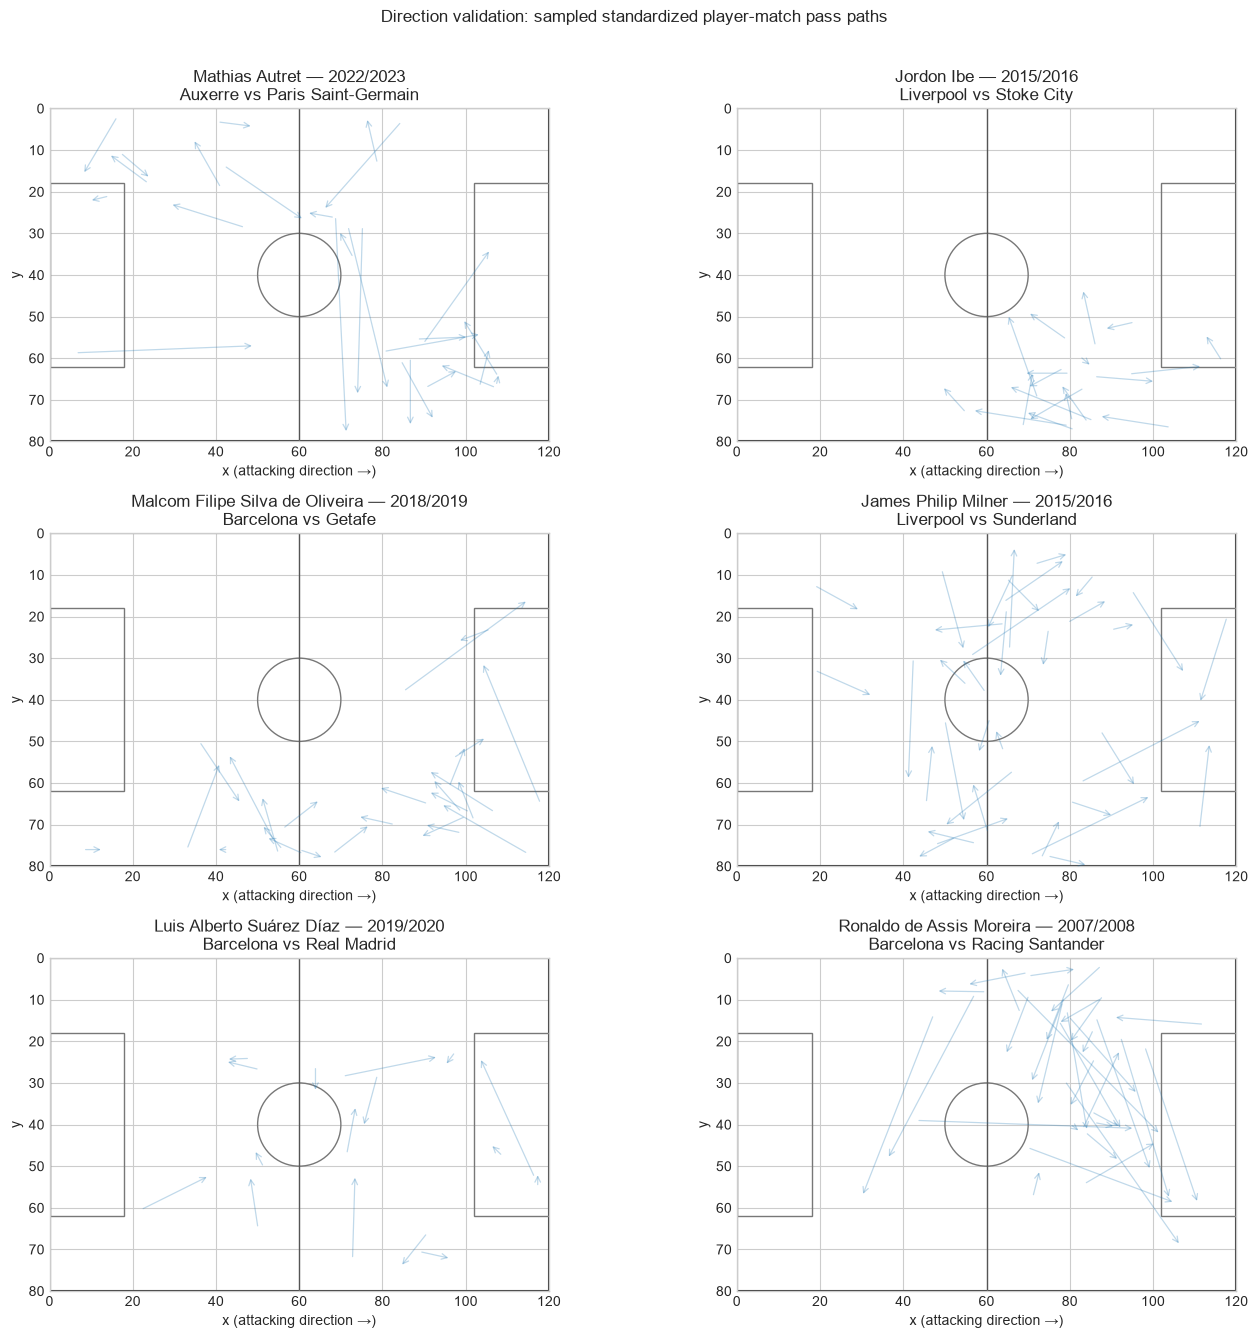

In [8]:
def draw_pitch(ax, title=None):
    """Draw a simple 120 by 80 StatsBomb-coordinate pitch."""
    length = CONFIG["pitch_length"]
    width = CONFIG["pitch_width"]
    ax.add_patch(Rectangle((0, 0), length, width, fill=False, lw=1.5, color="#333333"))
    ax.plot([length / 2, length / 2], [0, width], color="#555555", lw=1)
    ax.add_patch(Circle((length / 2, width / 2), 10, fill=False, color="#777777", lw=1))
    ax.add_patch(Rectangle((0, 18), 18, 44, fill=False, color="#777777", lw=1))
    ax.add_patch(Rectangle((length - 18, 18), 18, 44, fill=False, color="#777777", lw=1))
    ax.set_xlim(0, length)
    ax.set_ylim(width, 0)
    ax.set_aspect("equal")
    ax.set_xlabel("x (attacking direction →)")
    ax.set_ylabel("y")
    if title:
        ax.set_title(title)


validation_count = min(6, len(sample_records))
validation_indices = RNG.choice(len(sample_records), size=validation_count, replace=False)
fig, axes = plt.subplots(
    math.ceil(validation_count / 2), 2, figsize=(14, 4.4 * math.ceil(validation_count / 2))
)
axes = np.atleast_1d(axes).ravel()
for ax, sample_index in zip(axes, validation_indices):
    sample = sample_records[int(sample_index)]
    draw_pitch(
        ax,
        f"{sample['player_name']} — {sample['season_name']}\n"
        f"{sample['team']} vs {sample['opponent']}",
    )
    for pass_record in sample["passes"][:40]:
        start, end = pass_record["start"], pass_record["end"]
        ax.annotate(
            "",
            xy=end,
            xytext=start,
            arrowprops={"arrowstyle": "->", "color": "#1f77b4", "alpha": 0.28, "lw": 0.9},
        )
for ax in axes[validation_count:]:
    ax.axis("off")
fig.suptitle("Direction validation: sampled standardized player-match pass paths", y=1.01)
plt.tight_layout()
plt.show()

# 8. Create the 8 × 6 Pass-Transition Matrix

### Step-by-step logic

1. The 120 × 80 pitch is divided into 8 columns and 6 rows, giving 48 zones.
2. Every pass receives one start zone and one end zone.
3. A 48 × 48 matrix counts routes from each start zone to each end zone.
4. The matrix is flattened to 2,304 features and divided by its row total.

Each sample therefore sums to one and describes a distribution of routes, not passing volume. Total valid passes remain metadata only. A SciPy sparse matrix avoids storing the many zero transitions.

In [9]:
def location_to_zone(location):
    """Map a valid StatsBomb coordinate to a zero-based 8 by 6 zone id."""
    x, y = location
    column = min(
        int(x / CONFIG["pitch_length"] * CONFIG["grid_columns"]),
        CONFIG["grid_columns"] - 1,
    )
    row = min(
        int(y / CONFIG["pitch_width"] * CONFIG["grid_rows"]),
        CONFIG["grid_rows"] - 1,
    )
    return row * CONFIG["grid_columns"] + column


feature_rows = []
feature_columns = []
feature_values = []
valid_sample_records = []

for sample in sample_records:
    transition_counts = Counter()
    for pass_record in sample["passes"]:
        start_zone = location_to_zone(pass_record["start"])
        end_zone = location_to_zone(pass_record["end"])
        feature_index = start_zone * CONFIG["total_zones"] + end_zone
        transition_counts[feature_index] += 1
    total = sum(transition_counts.values())
    if total <= 0:
        continue
    row_index = len(valid_sample_records)
    for column_index, count in transition_counts.items():
        feature_rows.append(row_index)
        feature_columns.append(column_index)
        feature_values.append(count / total)
    valid_sample_records.append(sample)

sample_records = valid_sample_records
number_of_features = CONFIG["total_zones"] ** 2
X_routes = sparse.csr_matrix(
    (feature_values, (feature_rows, feature_columns)),
    shape=(len(sample_records), number_of_features),
    dtype=np.float64,
)
row_sums = np.asarray(X_routes.sum(axis=1)).ravel()
valid_rows = np.isfinite(row_sums) & (row_sums > 0)
X_routes = X_routes[valid_rows]
sample_records = [row for row, keep in zip(sample_records, valid_rows) if keep]
sample_metadata = pd.DataFrame(
    [
        {key: value for key, value in row.items() if key not in {"passes_raw", "passes"}}
        for row in sample_records
    ]
).reset_index(drop=True)

sparsity_percentage = 100 * (
    1 - X_routes.nnz / (X_routes.shape[0] * X_routes.shape[1])
)
print(f"Final feature-matrix shape: {X_routes.shape}")
print(f"Non-zero entries: {X_routes.nnz:,}")
print(f"Sparsity: {sparsity_percentage:.2f}%")
print(f"Row-sum range: {row_sums[valid_rows].min():.6f} to {row_sums[valid_rows].max():.6f}")

Final feature-matrix shape: (5104, 2304)
Non-zero entries: 107,433
Sparsity: 99.09%
Row-sum range: 1.000000 to 1.000000


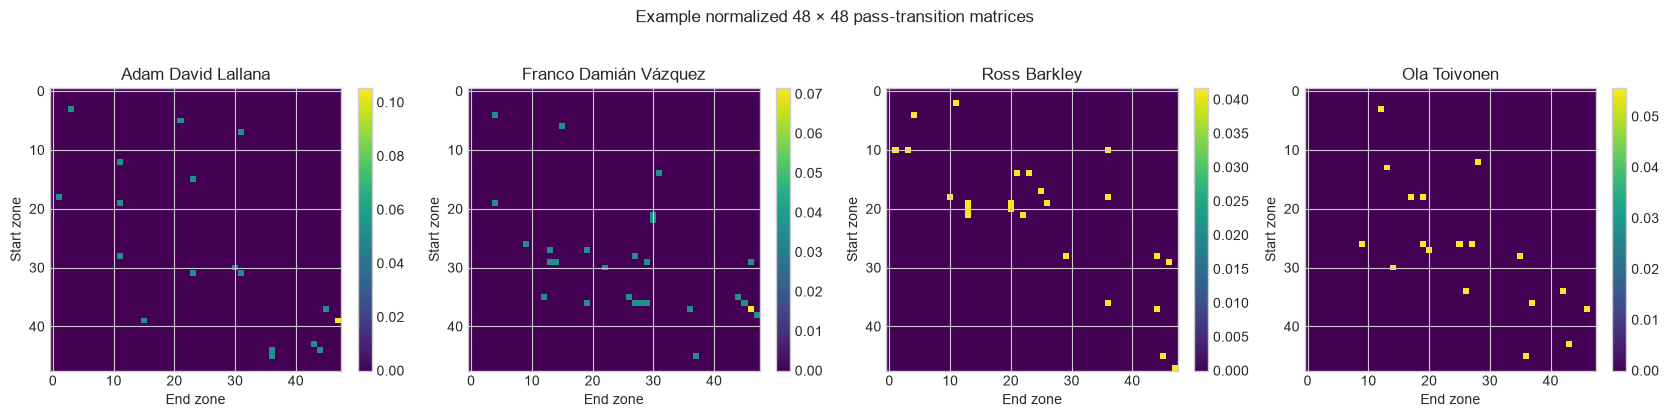

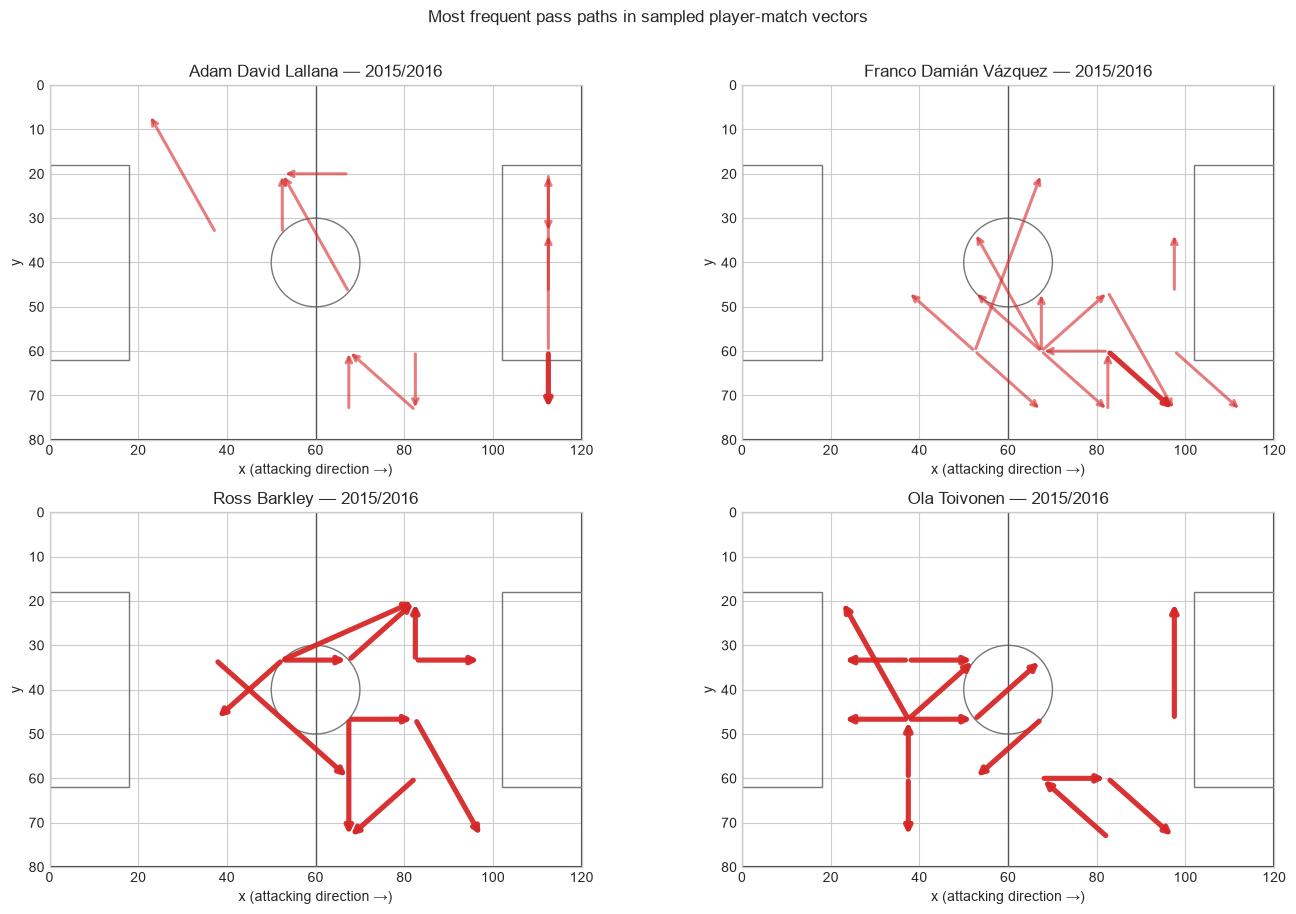

In [10]:
def zone_center(zone_id):
    """Return the center coordinate of a zero-based pitch zone."""
    row, column = divmod(int(zone_id), CONFIG["grid_columns"])
    return (
        (column + 0.5) * CONFIG["pitch_length"] / CONFIG["grid_columns"],
        (row + 0.5) * CONFIG["pitch_width"] / CONFIG["grid_rows"],
    )


def plot_route_vector(ax, route_vector, title, top_n=15, color="#d62728"):
    """Plot the highest-weight flattened start-to-end transitions as arrows."""
    values = np.asarray(route_vector).ravel()
    positive = np.flatnonzero(values > 0)
    if positive.size == 0:
        draw_pitch(ax, title)
        return
    ranked = positive[np.argsort(values[positive])[-top_n:][::-1]]
    scale = values[ranked].max()
    draw_pitch(ax, title)
    for feature_index in ranked:
        start_zone, end_zone = divmod(int(feature_index), CONFIG["total_zones"])
        start, end = zone_center(start_zone), zone_center(end_zone)
        weight = values[feature_index] / scale
        ax.annotate(
            "",
            xy=end,
            xytext=start,
            arrowprops={
                "arrowstyle": "->",
                "color": color,
                "alpha": 0.25 + 0.7 * weight,
                "lw": 0.7 + 3.0 * weight,
            },
        )


example_count = min(4, X_routes.shape[0])
example_indices = RNG.choice(X_routes.shape[0], size=example_count, replace=False)

fig, axes = plt.subplots(1, example_count, figsize=(4.2 * example_count, 4))
axes = np.atleast_1d(axes)
for ax, row_index in zip(axes, example_indices):
    transition_matrix = X_routes[int(row_index)].toarray().reshape(
        CONFIG["total_zones"], CONFIG["total_zones"]
    )
    image = ax.imshow(transition_matrix, aspect="auto", cmap="viridis")
    ax.set_title(sample_metadata.loc[int(row_index), "player_name"])
    ax.set_xlabel("End zone")
    ax.set_ylabel("Start zone")
    fig.colorbar(image, ax=ax, fraction=0.046)
fig.suptitle("Example normalized 48 × 48 pass-transition matrices", y=1.03)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, row_index in zip(axes.ravel(), example_indices):
    row = sample_metadata.loc[int(row_index)]
    plot_route_vector(
        ax,
        X_routes[int(row_index)].toarray().ravel(),
        f"{row['player_name']} — {row['season_name']}",
    )
for ax in axes.ravel()[example_count:]:
    ax.axis("off")
fig.suptitle("Most frequent pass paths in sampled player-match vectors", y=1.01)
plt.tight_layout()
plt.show()

# 9. Fit NMF

### Why NMF

The route matrix is non-negative and sparse. NMF represents each match as additive weights over ten learned route components, which is easier to inspect than arbitrary signed dimensions. All eligible samples, including Messi, are used because this is an exploratory unsupervised baseline.

Component descriptions below are generated only after inspecting each learned component's strongest paths. They are descriptive summaries, not definitive tactical role names.

In [11]:
if X_routes.shape[0] < CONFIG["nmf_components"]:
    raise RuntimeError(
        "There are fewer eligible samples than requested NMF components."
    )

nmf_model = NMF(
    n_components=CONFIG["nmf_components"],
    init="nndsvda",
    random_state=CONFIG["random_seed"],
    max_iter=1200,
)
W_nmf = nmf_model.fit_transform(X_routes)
H_nmf = nmf_model.components_

component_columns = [
    f"NMF Component {index + 1}" for index in range(CONFIG["nmf_components"])
]
component_summary = pd.DataFrame(W_nmf, columns=component_columns).describe().T
print(f"NMF reconstruction error: {nmf_model.reconstruction_err_:.6f}")
print(f"NMF iterations: {nmf_model.n_iter_}")
display(component_summary)

NMF reconstruction error: 15.309834
NMF iterations: 124


,count,mean,std,min,25%,50%,75%,max
NMF Component 1,5104.0,0.005620,0.010147,0.0,0.000000,0.000409,0.006925,0.126128
NMF Component 2,5104.0,0.015138,0.018542,0.0,0.000000,0.008426,0.023154,0.129275
NMF Component 3,5104.0,0.015830,0.015191,0.0,0.002610,0.012370,0.024903,0.092127
NMF Component 4,5104.0,0.008275,0.019241,0.0,0.000000,0.000202,0.002352,0.165390
NMF Component 5,5104.0,0.007472,0.017868,0.0,0.000000,0.000137,0.002251,0.259744
NMF Component 6,5104.0,0.010808,0.011023,0.0,0.001315,0.007873,0.016779,0.064037
NMF Component 7,5104.0,0.007209,0.016673,0.0,0.000000,0.000038,0.003097,0.203956
NMF Component 8,5104.0,0.006481,0.015270,0.0,0.000000,0.000311,0.002504,0.147598
NMF Component 9,5104.0,0.008213,0.015185,0.0,0.000000,0.000367,0.013070,0.165460
NMF Component 10,5104.0,0.009662,0.013502,0.0,0.000000,0.003931,0.014518,0.113280


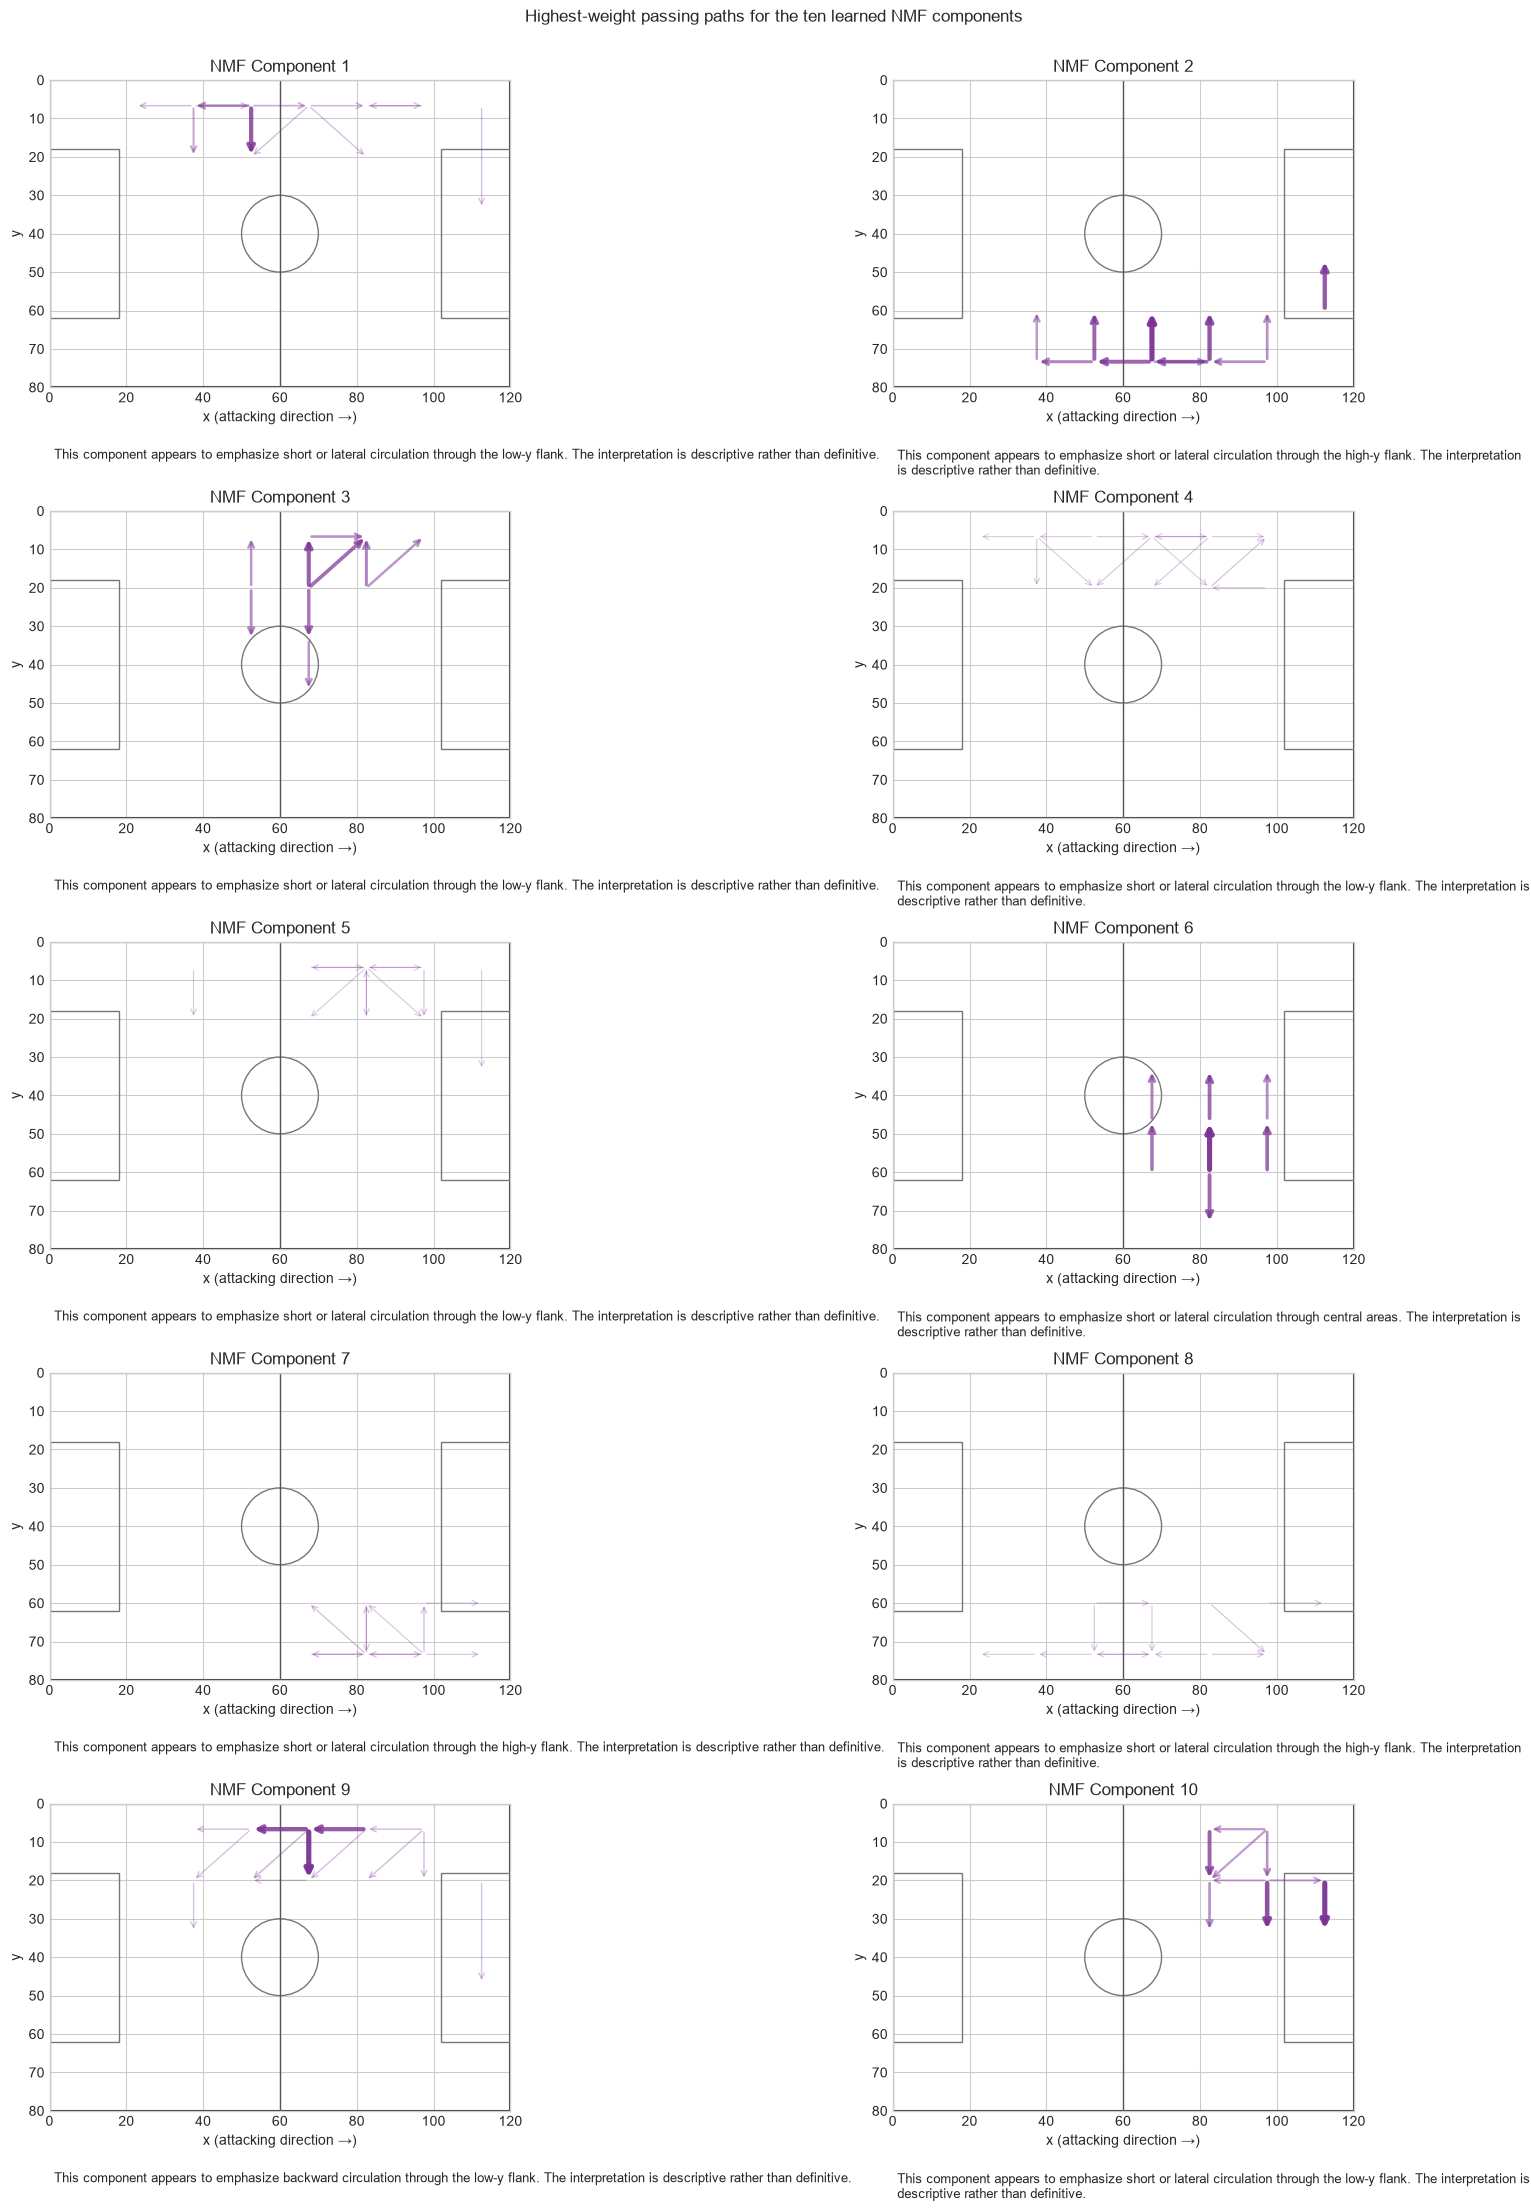

NMF Component 1: This component appears to emphasize short or lateral circulation through the low-y flank. The interpretation is descriptive rather than definitive.
NMF Component 2: This component appears to emphasize short or lateral circulation through the high-y flank. The interpretation is descriptive rather than definitive.
NMF Component 3: This component appears to emphasize short or lateral circulation through the low-y flank. The interpretation is descriptive rather than definitive.
NMF Component 4: This component appears to emphasize short or lateral circulation through the low-y flank. The interpretation is descriptive rather than definitive.
NMF Component 5: This component appears to emphasize short or lateral circulation through the low-y flank. The interpretation is descriptive rather than definitive.
NMF Component 6: This component appears to emphasize short or lateral circulation through central areas. The interpretation is descriptive rather than definitive.
NMF Compone

In [12]:
def describe_route_pattern(route_vector):
    """Create a neutral geometry-based description from the strongest transitions."""
    values = np.asarray(route_vector).ravel()
    top = np.argsort(values)[-20:]
    weights = values[top]
    if weights.sum() <= 0:
        return "This component has no stable positive route emphasis."
    starts, ends = [], []
    for feature_index in top:
        start_zone, end_zone = divmod(int(feature_index), CONFIG["total_zones"])
        starts.append(zone_center(start_zone))
        ends.append(zone_center(end_zone))
    starts = np.asarray(starts)
    ends = np.asarray(ends)
    mean_start = np.average(starts, axis=0, weights=weights)
    mean_end = np.average(ends, axis=0, weights=weights)
    mean_dx = mean_end[0] - mean_start[0]
    if mean_dx > 12:
        progression = "forward progression"
    elif mean_dx < -8:
        progression = "backward circulation"
    else:
        progression = "short or lateral circulation"
    mean_y = (mean_start[1] + mean_end[1]) / 2
    if mean_y < CONFIG["pitch_width"] / 3:
        channel = "the low-y flank"
    elif mean_y > 2 * CONFIG["pitch_width"] / 3:
        channel = "the high-y flank"
    else:
        channel = "central areas"
    return (
        f"This component appears to emphasize {progression} through {channel}. "
        "The interpretation is descriptive rather than definitive."
    )


component_interpretations = [
    describe_route_pattern(H_nmf[index])
    for index in range(CONFIG["nmf_components"])
]
fig, axes = plt.subplots(5, 2, figsize=(15, 22))
for index, ax in enumerate(axes.ravel()):
    label = component_columns[index]
    plot_route_vector(ax, H_nmf[index], label, top_n=14, color="#7b3294")
    ax.text(
        0.01,
        -0.20,
        component_interpretations[index],
        transform=ax.transAxes,
        fontsize=9,
        va="top",
        wrap=True,
    )
fig.suptitle("Highest-weight passing paths for the ten learned NMF components", y=1.002)
plt.tight_layout()
plt.show()

for label, interpretation in zip(component_columns, component_interpretations):
    print(f"{label}: {interpretation}")

# 10. Fit a Five-Cluster GMM

### Key ideas

NMF dimensions can have different scales, so `StandardScaler` is fitted before clustering. A five-component GMM with diagonal covariance is a simpler, more stable baseline than estimating every covariance interaction. Ten initialization attempts reduce dependence on one starting solution.

GMM posterior probabilities preserve uncertainty. PCA is fitted only to create a two-dimensional picture; it is not the clustering input.

In [13]:
scaler = StandardScaler()
Z_nmf = scaler.fit_transform(W_nmf)

gmm_model = GaussianMixture(
    n_components=CONFIG["gmm_clusters"],
    covariance_type="diag",
    n_init=10,
    max_iter=500,
    random_state=CONFIG["random_seed"],
)
zero_based_clusters = gmm_model.fit_predict(Z_nmf)
cluster_probabilities = gmm_model.predict_proba(Z_nmf)
primary_clusters = zero_based_clusters + 1

sample_metadata["primary_cluster"] = primary_clusters
sample_metadata["maximum_cluster_probability"] = cluster_probabilities.max(axis=1)
for index in range(CONFIG["gmm_clusters"]):
    sample_metadata[f"cluster_{index + 1}_probability"] = cluster_probabilities[:, index]
for index, column in enumerate(component_columns):
    sample_metadata[column] = W_nmf[:, index]

cluster_sizes = (
    sample_metadata["primary_cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .to_frame("Player-match samples")
)
cluster_component_means = sample_metadata.groupby("primary_cluster")[
    component_columns
].mean()
position_by_cluster = pd.crosstab(
    sample_metadata["primary_cluster"],
    sample_metadata["primary_attacking_position"],
    normalize="index",
)
competition_by_cluster = pd.crosstab(
    sample_metadata["primary_cluster"],
    sample_metadata["competition_name"],
    normalize="index",
)
season_by_cluster = pd.crosstab(
    sample_metadata["primary_cluster"],
    sample_metadata["season_name"],
    normalize="index",
)

display(cluster_sizes)
display(cluster_component_means.style.format("{:.4f}"))
display(position_by_cluster.style.format("{:.1%}"))
display(competition_by_cluster.style.format("{:.1%}"))
display(season_by_cluster.style.format("{:.1%}"))
print(
    "Average maximum GMM assignment probability: "
    f"{sample_metadata['maximum_cluster_probability'].mean():.3f}"
)

,Player-match samples
Cluster,
1,1172
2,763
3,1300
4,937
5,932


,NMF Component 1,NMF Component 2,NMF Component 3,NMF Component 4,NMF Component 5,NMF Component 6,NMF Component 7,NMF Component 8,NMF Component 9,NMF Component 10
primary_cluster,,,,,,,,,,
1,0.0000,0.0279,0.0105,0.0001,0.0001,0.0163,0.0132,0.0117,0.0000,0.0046
2,0.0112,0.0000,0.0220,0.0159,0.0156,0.0069,0.0000,0.0000,0.0184,0.0205
3,0.0051,0.0155,0.0189,0.0008,0.0008,0.0121,0.0011,0.0012,0.0062,0.0074
4,0.0092,0.0077,0.0166,0.0220,0.0190,0.0068,0.0006,0.0006,0.0143,0.0134
5,0.0051,0.0183,0.0125,0.0089,0.0078,0.0093,0.0207,0.0186,0.0069,0.0065


primary_attacking_position,Center Attacking Midfield,Center Forward,Left Attacking Midfield,Left Wing,Right Attacking Midfield,Right Wing
primary_cluster,,,,,,
1,15.7%,17.4%,0.1%,2.6%,2.9%,61.3%
2,10.4%,10.0%,2.0%,74.4%,0.5%,2.8%
3,34.8%,18.8%,1.8%,17.8%,2.1%,24.5%
4,25.2%,13.1%,2.6%,51.0%,0.5%,7.6%
5,29.7%,14.5%,2.0%,16.5%,1.6%,35.6%


competition_name,1. Bundesliga,Indian Super league,La Liga,Liga Profesional,Ligue 1,Major League Soccer,North American League,Premier League,Serie A
primary_cluster,,,,,,,,,
1,2.1%,2.8%,48.5%,0.1%,17.4%,0.1%,0.1%,16.3%,12.5%
2,1.6%,2.9%,50.2%,0.1%,15.2%,0.0%,0.3%,17.4%,12.3%
3,2.8%,4.4%,35.2%,0.0%,19.4%,0.1%,0.2%,26.0%,12.0%
4,3.9%,2.8%,35.8%,0.1%,23.2%,0.1%,0.0%,21.7%,12.5%
5,3.5%,1.9%,35.0%,0.1%,24.2%,0.2%,0.1%,22.5%,12.3%


season_name,1973/1974,1977,1981,1997/1998,2003/2004,2004/2005,2005/2006,2006/2007,2007/2008,2008/2009,2009/2010,2010/2011,2011/2012,2012/2013,2013/2014,2014/2015,2015/2016,2016/2017,2017/2018,2018/2019,2019/2020,2020/2021,2021/2022,2022/2023,2023,2023/2024
primary_cluster,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.1%,0.1%,0.0%,0.1%,0.2%,0.5%,0.9%,2.1%,1.5%,1.2%,1.6%,2.4%,2.6%,4.2%,2.3%,3.1%,59.0%,2.3%,1.6%,2.7%,1.5%,2.1%,4.6%,1.5%,0.1%,1.7%
2,0.1%,0.3%,0.1%,0.0%,0.3%,0.7%,1.3%,2.6%,2.0%,1.8%,1.3%,1.4%,1.8%,3.4%,2.9%,2.6%,59.5%,3.0%,1.3%,2.5%,1.4%,1.7%,5.4%,1.6%,0.0%,0.9%
3,0.1%,0.2%,0.0%,0.0%,0.2%,0.4%,1.0%,1.2%,0.9%,1.6%,2.2%,1.2%,1.4%,1.5%,2.1%,1.3%,70.8%,1.0%,0.9%,1.2%,0.9%,1.1%,5.9%,1.2%,0.1%,1.8%
4,0.0%,0.0%,0.1%,0.0%,0.0%,0.1%,0.6%,0.7%,1.1%,1.6%,1.4%,1.8%,2.2%,1.3%,1.1%,1.8%,72.7%,1.0%,1.4%,0.6%,1.0%,1.4%,4.6%,1.6%,0.1%,1.8%
5,0.0%,0.1%,0.0%,0.1%,0.3%,0.1%,0.6%,1.0%,0.6%,1.2%,1.8%,1.8%,2.0%,1.5%,1.2%,1.8%,74.2%,0.4%,1.3%,0.6%,1.4%,1.1%,3.5%,1.0%,0.2%,1.9%


Average maximum GMM assignment probability: 0.983


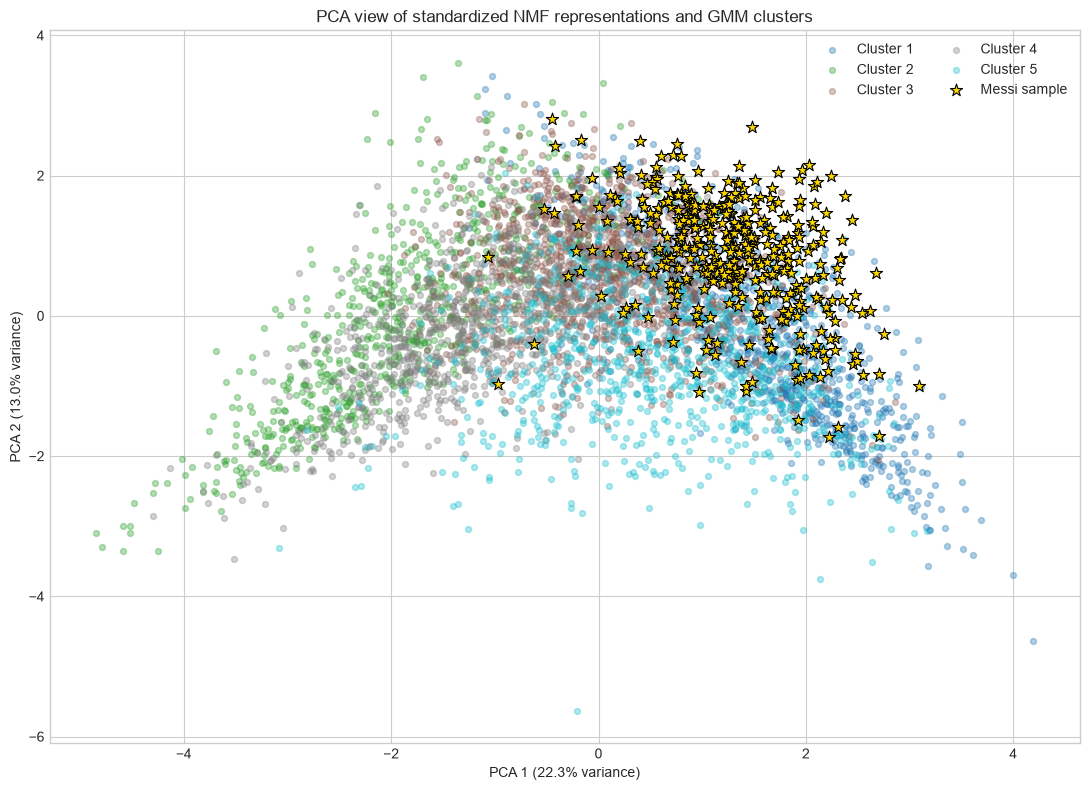

In [14]:
pca_model = PCA(n_components=2, random_state=CONFIG["random_seed"])
pca_coordinates = pca_model.fit_transform(Z_nmf)
messi_name_mask = sample_metadata["player_name"].str.contains(
    "Messi", case=False, na=False
)

fig, ax = plt.subplots(figsize=(11, 8))
palette = plt.cm.tab10(np.linspace(0, 1, CONFIG["gmm_clusters"]))
for cluster_number, color in zip(range(1, CONFIG["gmm_clusters"] + 1), palette):
    mask = sample_metadata["primary_cluster"].eq(cluster_number).to_numpy()
    ax.scatter(
        pca_coordinates[mask, 0],
        pca_coordinates[mask, 1],
        s=18,
        alpha=0.35,
        color=color,
        label=f"Cluster {cluster_number}",
    )
if messi_name_mask.any():
    ax.scatter(
        pca_coordinates[messi_name_mask, 0],
        pca_coordinates[messi_name_mask, 1],
        s=85,
        marker="*",
        facecolor="gold",
        edgecolor="black",
        linewidth=0.8,
        label="Messi sample",
        zorder=5,
    )
ax.set_title("PCA view of standardized NMF representations and GMM clusters")
ax.set_xlabel(f"PCA 1 ({pca_model.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PCA 2 ({pca_model.explained_variance_ratio_[1]:.1%} variance)")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

# 11. Interpret the Five Clusters

### What to inspect

A cluster's average transition vector shows its recurring routes. High-posterior matches are the most representative samples under the fitted GMM. Position, player, and team frequency tables are necessary context: a cluster may reflect passing style, attacking position, team possession structure, competition coverage, or a mixture.

The interpretation function remains geometric and cautious. It does not name a unique tactical role.

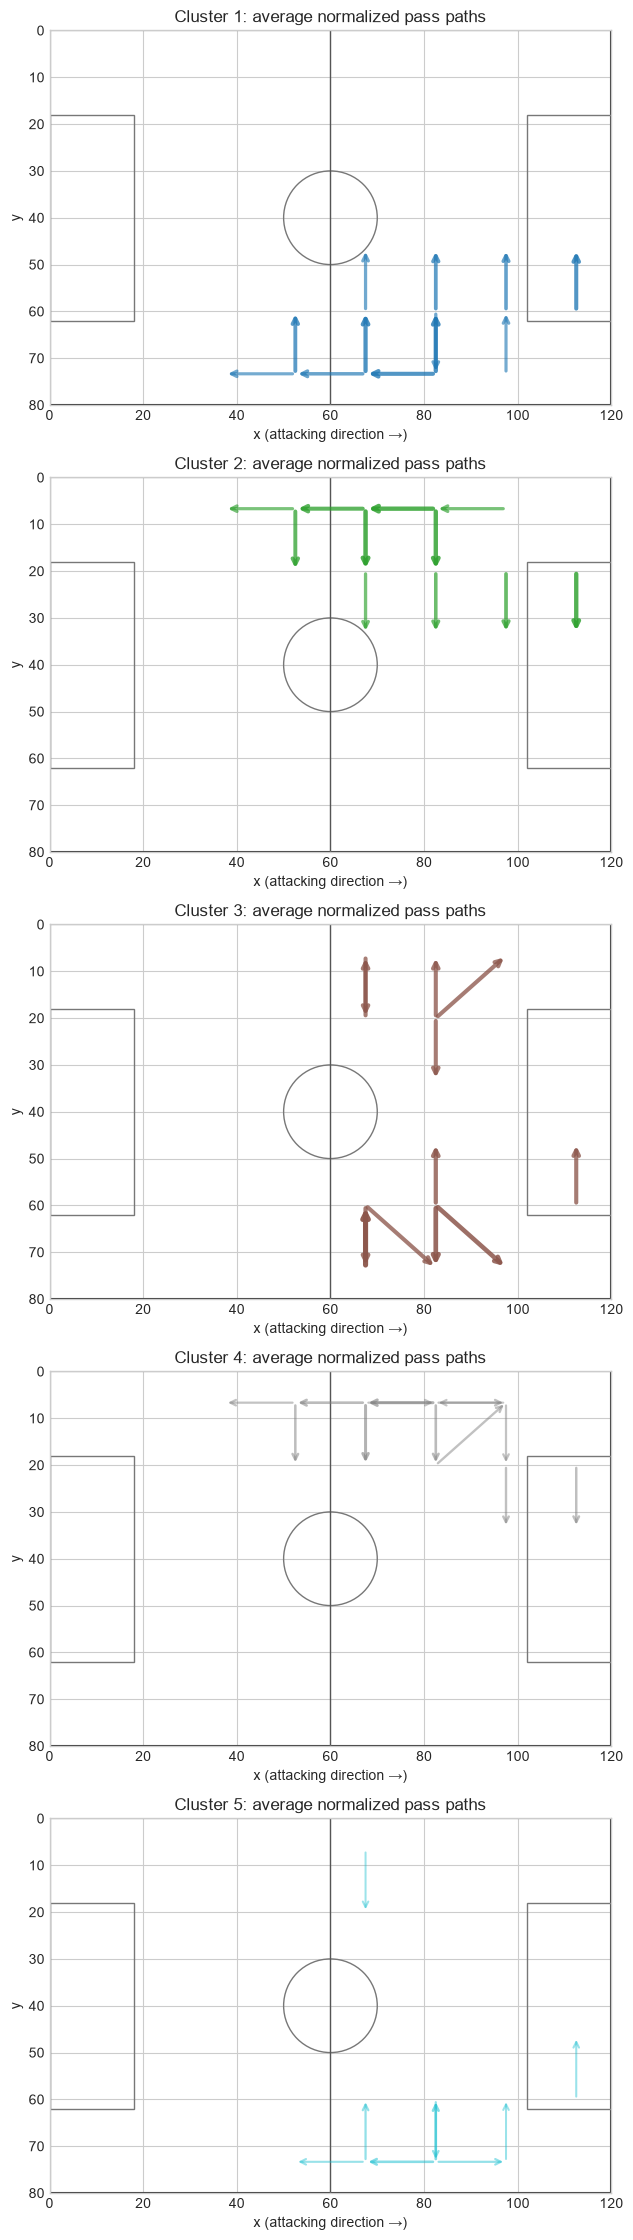


Cluster 1
This component appears to emphasize short or lateral circulation through the high-y flank. The interpretation is descriptive rather than definitive.


,player_name,team,opponent,season_name,primary_attacking_position,valid_passes,cluster_1_probability
0,Lionel Andrés Messi Cuccittini,Barcelona,Real Sociedad,2010/2011,Center Forward,42,1.0
1,Alexis Alejandro Sánchez Sánchez,Barcelona,Athletic Club,2011/2012,Right Wing,17,1.0
2,Lionel Andrés Messi Cuccittini,Barcelona,Valencia,2014/2015,Right Wing,35,1.0
3,Lionel Andrés Messi Cuccittini,Barcelona,Getafe,2009/2010,Right Wing,23,1.0
4,Lionel Andrés Messi Cuccittini,Barcelona,Athletic Club,2006/2007,Right Wing,15,1.0
5,Ousmane Dembélé,Barcelona,Granada,2020/2021,Right Wing,23,1.0
6,Lionel Andrés Messi Cuccittini,Barcelona,Granada,2015/2016,Right Wing,29,1.0
7,Mohamed Salah,AS Roma,Juventus,2015/2016,Right Wing,23,1.0


,Top positions,Top players,Top teams
Right Wing,719.0,NaN,NaN
Center Forward,204.0,NaN,NaN
Center Attacking Midfield,184.0,NaN,NaN
Right Attacking Midfield,34.0,NaN,NaN
Left Wing,30.0,NaN,NaN
Lionel Andrés Messi Cuccittini,NaN,228.0,NaN
Pedro Eliezer Rodríguez Ledesma,NaN,24.0,NaN
Alexis Alejandro Sánchez Sánchez,NaN,23.0,NaN
José María Callejón Bueno,NaN,19.0,NaN
Xabier Prieto Argarate,NaN,15.0,NaN



Cluster 2
This component appears to emphasize short or lateral circulation through the low-y flank. The interpretation is descriptive rather than definitive.


,player_name,team,opponent,season_name,primary_attacking_position,valid_passes,cluster_2_probability
0,Stephan El Shaarawy,AS Roma,Napoli,2015/2016,Left Wing,18,1.0
1,Kylian Mbappé Lottin,Paris Saint-Germain,Troyes,2022/2023,Left Wing,16,1.0
2,Vincent Bessat,Stade Malherbe Caen,Montpellier,2015/2016,Left Wing,17,1.0
3,Théo Bongonda Mbul''Ofeko Batombo,Celta Vigo,Sevilla,2015/2016,Left Wing,15,1.0
4,Vinícius José Paixão de Oliveira Júnior,Real Madrid,Barcelona,2018/2019,Left Wing,16,1.0
5,Neymar da Silva Santos Junior,Paris Saint-Germain,Lyon,2022/2023,Left Attacking Midfield,33,1.0
6,Anssumane Fati,Barcelona,Osasuna,2019/2020,Left Wing,37,1.0
7,Pedro Eliezer Rodríguez Ledesma,Barcelona,Rayo Vallecano,2013/2014,Left Wing,18,1.0


...

,Top positions,Top players,Top teams
Left Wing,478.0,NaN,NaN
Center Attacking Midfield,236.0,NaN,NaN
Center Forward,123.0,NaN,NaN
Right Wing,71.0,NaN,NaN
Left Attacking Midfield,24.0,NaN,NaN
Neymar da Silva Santos Junior,NaN,23.0,NaN
Pedro Eliezer Rodríguez Ledesma,NaN,18.0,NaN
Lionel Andrés Messi Cuccittini,NaN,16.0,NaN
Andrés Iniesta Luján,NaN,12.0,NaN
Sofiane Boufal,NaN,11.0,NaN



Cluster 5
This component appears to emphasize short or lateral circulation through the high-y flank. The interpretation is descriptive rather than definitive.


,player_name,team,opponent,season_name,primary_attacking_position,valid_passes,cluster_5_probability
0,Karim Bellarabi,Bayer Leverkusen,Hertha Berlin,2015/2016,Right Wing,26,1.0
1,Leroy Sané,Schalke 04,Bayer Leverkusen,2015/2016,Right Wing,21,1.0
2,Julian Brandt,Bayer Leverkusen,Eintracht Frankfurt,2015/2016,Left Wing,28,1.0
3,Hakan Çalhanoğlu,Bayer Leverkusen,FC Köln,2015/2016,Center Attacking Midfield,26,1.0
4,Ja-Cheol Koo,Augsburg,Bayer Leverkusen,2015/2016,Center Attacking Midfield,15,1.0
5,Julian Brandt,Bayer Leverkusen,Werder Bremen,2015/2016,Center Attacking Midfield,15,1.0
6,Mathew Leckie,Ingolstadt,Bayer Leverkusen,2015/2016,Center Forward,18,1.0
7,Alfredo Morales,Ingolstadt,Bayer Leverkusen,2015/2016,Left Wing,21,1.0


,Top positions,Top players,Top teams
Right Wing,332.0,NaN,NaN
Center Attacking Midfield,277.0,NaN,NaN
Left Wing,154.0,NaN,NaN
Center Forward,135.0,NaN,NaN
Left Attacking Midfield,19.0,NaN,NaN
Lionel Andrés Messi Cuccittini,NaN,45.0,NaN
Pedro Eliezer Rodríguez Ledesma,NaN,22.0,NaN
Rémy Cabella,NaN,13.0,NaN
Mathieu Valbuena,NaN,13.0,NaN
Antoine Griezmann,NaN,10.0,NaN


Interpretive caution: these clusters appear to combine route geometry with position and team possession context. The frequency tables should be checked before describing any cluster as a distinct player role.


In [15]:
cluster_route_vectors = {}
cluster_interpretations = {}
fig, axes = plt.subplots(CONFIG["gmm_clusters"], 1, figsize=(14, 4.5 * CONFIG["gmm_clusters"]))
axes = np.atleast_1d(axes)

for cluster_number, ax in zip(range(1, CONFIG["gmm_clusters"] + 1), axes):
    mask = sample_metadata["primary_cluster"].eq(cluster_number).to_numpy()
    average_routes = np.asarray(X_routes[mask].mean(axis=0)).ravel()
    cluster_route_vectors[cluster_number] = average_routes
    cluster_interpretations[cluster_number] = describe_route_pattern(average_routes)
    plot_route_vector(
        ax,
        average_routes,
        f"Cluster {cluster_number}: average normalized pass paths",
        top_n=18,
        color=palette[cluster_number - 1],
    )
plt.tight_layout()
plt.show()

for cluster_number in range(1, CONFIG["gmm_clusters"] + 1):
    probability_column = f"cluster_{cluster_number}_probability"
    cluster_rows = sample_metadata[
        sample_metadata["primary_cluster"].eq(cluster_number)
    ]
    representatives = cluster_rows.nlargest(8, probability_column)[
        [
            "player_name",
            "team",
            "opponent",
            "season_name",
            "primary_attacking_position",
            "valid_passes",
            probability_column,
        ]
    ]
    top_positions = cluster_rows["primary_attacking_position"].value_counts().head(5)
    top_players = cluster_rows["player_name"].value_counts().head(8)
    top_teams = cluster_rows["team"].value_counts().head(8)

    print(f"\nCluster {cluster_number}")
    print(cluster_interpretations[cluster_number])
    display(representatives.reset_index(drop=True))
    display(
        pd.concat(
            [
                top_positions.rename("Top positions"),
                top_players.rename("Top players"),
                top_teams.rename("Top teams"),
            ],
            axis=1,
        )
    )

print(
    "Interpretive caution: these clusters appear to combine route geometry with "
    "position and team possession context. The frequency tables should be checked "
    "before describing any cluster as a distinct player role."
)

# 12. Identify Lionel Messi

### Identification rule

Eligible names are searched case-insensitively for `Messi`, covering full-name and short-name forms. Candidate IDs are displayed. If more than one stable ID appears, the ID with the largest number of eligible league samples is selected and the choice is reported.

In [16]:
messi_candidates = (
    sample_metadata[messi_name_mask]
    .groupby(["player_id", "player_name"], dropna=False)
    .size()
    .rename("Eligible samples")
    .reset_index()
    .sort_values("Eligible samples", ascending=False)
)
if messi_candidates.empty:
    raise RuntimeError(
        "No eligible domestic-league player-match sample with 'Messi' in the name was found."
    )

display(messi_candidates)
selected_messi_id = messi_candidates.iloc[0]["player_id"]
selected_messi_name = messi_candidates.iloc[0]["player_name"]
messi_mask = sample_metadata["player_id"].eq(selected_messi_id)
messi_metadata = sample_metadata[messi_mask].copy()
messi_indices = np.flatnonzero(messi_mask.to_numpy())

print(f"Selected Messi name: {selected_messi_name}")
print(f"Selected StatsBomb player ID: {selected_messi_id}")
print(f"Eligible league player-match samples: {len(messi_metadata):,}")
print("Competitions:", ", ".join(sorted(messi_metadata["competition_name"].unique())))
print("Teams:", ", ".join(sorted(messi_metadata["team"].unique())))
display(
    messi_metadata.groupby(["season_name", "team"])
    .size()
    .rename("Eligible matches")
    .reset_index()
)
if len(messi_candidates) > 1:
    print(
        "Multiple IDs matched. The ID with the most eligible samples was selected "
        "to keep the season analysis internally consistent."
    )

,player_id,player_name,Eligible samples
0,5503,Lionel Andrés Messi Cuccittini,382


Selected Messi name: Lionel Andrés Messi Cuccittini
Selected StatsBomb player ID: 5503
Eligible league player-match samples: 382
Competitions: La Liga, Ligue 1, Major League Soccer
Teams: Barcelona, Inter Miami, Paris Saint-Germain


,season_name,team,Eligible matches
0,2005/2006,Barcelona,5
1,2006/2007,Barcelona,17
2,2007/2008,Barcelona,13
3,2008/2009,Barcelona,21
4,2009/2010,Barcelona,23
5,2010/2011,Barcelona,30
6,2011/2012,Barcelona,29
7,2012/2013,Barcelona,25
8,2013/2014,Barcelona,21
9,2014/2015,Barcelona,34


# 13. Messi Cluster Distribution by Season

### What this cell calculates

For each season, the table reports eligible matches, hard-cluster counts and percentages, mean soft probability for every cluster, and mean maximum assignment probability. Seasons are ordered by the first four-digit year in the label.

Fewer than five eligible matches is flagged as **Low sample size**. Such seasons remain visible but should not support strong conclusions.

,Eligible matches,Average maximum probability,Reliability flag,Cluster 1 matches,Cluster 1 percentage,Cluster 1 average probability,Cluster 2 matches,Cluster 2 percentage,Cluster 2 average probability,Cluster 3 matches,Cluster 3 percentage,Cluster 3 average probability,Cluster 4 matches,Cluster 4 percentage,Cluster 4 average probability,Cluster 5 matches,Cluster 5 percentage,Cluster 5 average probability
Season,,,,,,,,,,,,,,,,,,
2005/2006,5,96.3%,Reliable baseline,3,60.0%,63.6%,0,0.0%,0.0%,2,40.0%,36.4%,0,0.0%,0.0%,0,0.0%,0.0%
2006/2007,17,100.0%,Reliable baseline,11,64.7%,64.7%,1,5.9%,5.9%,4,23.5%,23.5%,0,0.0%,0.0%,1,5.9%,5.9%
2007/2008,13,99.8%,Reliable baseline,9,69.2%,69.1%,1,7.7%,7.7%,3,23.1%,23.2%,0,0.0%,0.0%,0,0.0%,0.0%
2008/2009,21,99.7%,Reliable baseline,9,42.9%,42.9%,1,4.8%,4.8%,3,14.3%,14.3%,1,4.8%,4.4%,7,33.3%,33.7%
2009/2010,23,99.4%,Reliable baseline,12,52.2%,52.2%,2,8.7%,8.7%,5,21.7%,21.7%,1,4.3%,3.7%,3,13.0%,13.7%
2010/2011,30,97.2%,Reliable baseline,16,53.3%,53.0%,3,10.0%,10.3%,5,16.7%,16.7%,4,13.3%,13.2%,2,6.7%,6.8%
2011/2012,29,100.0%,Reliable baseline,15,51.7%,51.7%,2,6.9%,6.9%,4,13.8%,13.8%,0,0.0%,0.0%,8,27.6%,27.6%
2012/2013,25,98.6%,Reliable baseline,20,80.0%,78.6%,3,12.0%,13.4%,1,4.0%,4.0%,0,0.0%,0.0%,1,4.0%,4.0%
2013/2014,21,99.7%,Reliable baseline,11,52.4%,52.4%,3,14.3%,14.3%,5,23.8%,23.8%,1,4.8%,4.5%,1,4.8%,5.0%


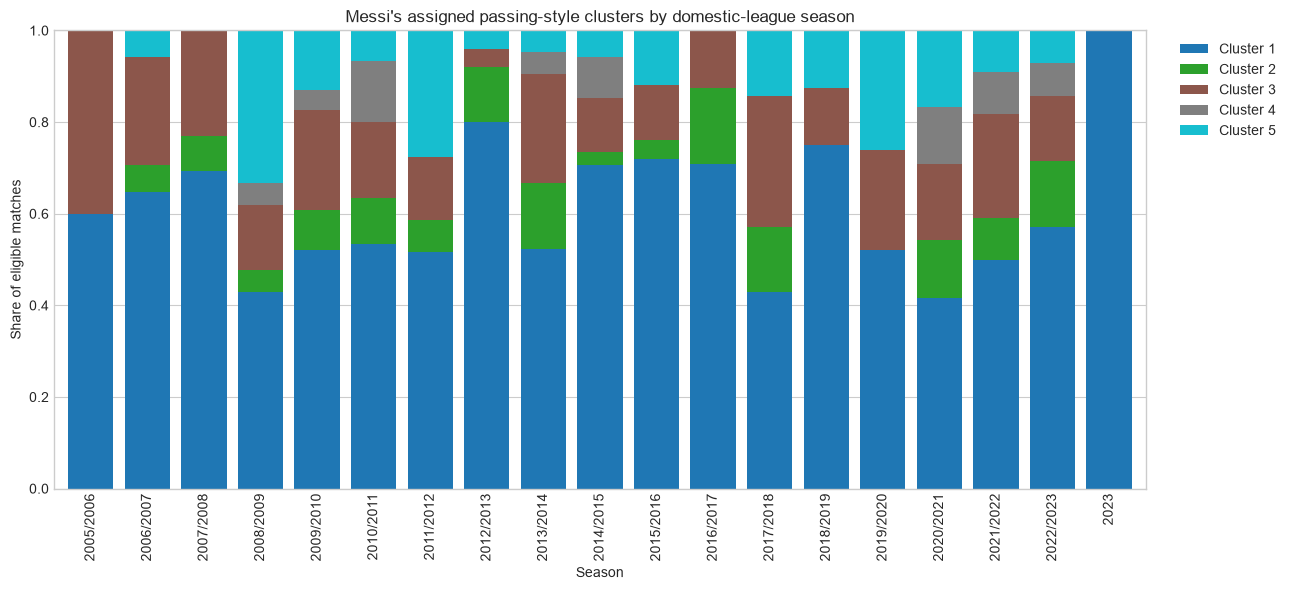

In [17]:
def season_sort_key(label):
    """Extract a chronological key from a season label without assuming one format."""
    years = re.findall(r"(?:19|20)\d{2}", str(label))
    return (int(years[0]) if years else 9999, str(label))


ordered_messi_seasons = sorted(
    messi_metadata["season_name"].unique(), key=season_sort_key
)
probability_columns = [
    f"cluster_{index}_probability"
    for index in range(1, CONFIG["gmm_clusters"] + 1)
]
season_cluster_rows = []
for season in ordered_messi_seasons:
    group = messi_metadata[messi_metadata["season_name"].eq(season)]
    row = {
        "Season": season,
        "Eligible matches": len(group),
        "Average maximum probability": group["maximum_cluster_probability"].mean(),
        "Reliability flag": (
            "Reliable baseline"
            if len(group) >= CONFIG["minimum_reliable_messi_matches"]
            else "Low sample size"
        ),
    }
    for cluster_number in range(1, CONFIG["gmm_clusters"] + 1):
        count = int(group["primary_cluster"].eq(cluster_number).sum())
        row[f"Cluster {cluster_number} matches"] = count
        row[f"Cluster {cluster_number} percentage"] = count / len(group)
        row[f"Cluster {cluster_number} average probability"] = group[
            f"cluster_{cluster_number}_probability"
        ].mean()
    season_cluster_rows.append(row)

messi_season_clusters = pd.DataFrame(season_cluster_rows).set_index("Season")
display(
    messi_season_clusters.style.format(
        {
            column: "{:.1%}"
            for column in messi_season_clusters.columns
            if "percentage" in column or "probability" in column.lower()
        }
    )
)

percentage_columns = [
    f"Cluster {index} percentage"
    for index in range(1, CONFIG["gmm_clusters"] + 1)
]
ax = messi_season_clusters[percentage_columns].plot(
    kind="bar",
    stacked=True,
    figsize=(13, 6),
    color=palette,
    width=0.8,
)
ax.set_title("Messi's assigned passing-style clusters by domestic-league season")
ax.set_xlabel("Season")
ax.set_ylabel("Share of eligible matches")
ax.set_ylim(0, 1)
ax.legend(
    [f"Cluster {index}" for index in range(1, CONFIG["gmm_clusters"] + 1)],
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()

# 14. Messi Season Centers in the Style Space

### Key ideas

A season center is the mean standardized ten-dimensional NMF vector across Messi's eligible matches. Consecutive-season distance is Euclidean distance between centers in that full ten-dimensional space. Within-season variability is the mean distance from matches to their own season center.

PCA is used only to draw the trajectory. It does not determine either distance.

In [18]:
season_centers = {}
season_summary_rows = []
previous_center = None

for season in ordered_messi_seasons:
    local_positions = np.flatnonzero(
        messi_metadata["season_name"].eq(season).to_numpy()
    )
    global_positions = messi_indices[local_positions]
    season_vectors = Z_nmf[global_positions]
    center = season_vectors.mean(axis=0)
    season_centers[season] = center
    within_variability = np.linalg.norm(season_vectors - center, axis=1).mean()
    consecutive_distance = (
        np.linalg.norm(center - previous_center)
        if previous_center is not None
        else np.nan
    )
    group = messi_metadata.iloc[local_positions]
    cluster_share = group["primary_cluster"].value_counts(normalize=True)
    dominant_cluster = int(cluster_share.index[0])
    season_summary_rows.append(
        {
            "Season": season,
            "Team": ", ".join(sorted(group["team"].unique())),
            "Eligible matches": len(group),
            "Dominant cluster": dominant_cluster,
            "Dominant-cluster percentage": cluster_share.iloc[0],
            "Consecutive-season distance": consecutive_distance,
            "Within-season variability": within_variability,
            "Reliability flag": (
                "Reliable baseline"
                if len(group) >= CONFIG["minimum_reliable_messi_matches"]
                else "Low sample size"
            ),
        }
    )
    previous_center = center

messi_season_summary = pd.DataFrame(season_summary_rows).set_index("Season")
display(
    messi_season_summary.style.format(
        {
            "Dominant-cluster percentage": "{:.1%}",
            "Consecutive-season distance": "{:.3f}",
            "Within-season variability": "{:.3f}",
        }
    )
)

,Team,Eligible matches,Dominant cluster,Dominant-cluster percentage,Consecutive-season distance,Within-season variability,Reliability flag
Season,,,,,,,
2005/2006,Barcelona,5,1,60.0%,nan,1.499,Reliable baseline
2006/2007,Barcelona,17,1,64.7%,0.838,2.317,Reliable baseline
2007/2008,Barcelona,13,1,69.2%,0.388,2.204,Reliable baseline
2008/2009,Barcelona,21,1,42.9%,0.721,2.240,Reliable baseline
2009/2010,Barcelona,23,1,52.2%,0.886,2.190,Reliable baseline
2010/2011,Barcelona,30,1,53.3%,0.705,1.686,Reliable baseline
2011/2012,Barcelona,29,1,51.7%,1.016,1.674,Reliable baseline
2012/2013,Barcelona,25,1,80.0%,0.597,1.726,Reliable baseline
2013/2014,Barcelona,21,1,52.4%,0.526,1.670,Reliable baseline


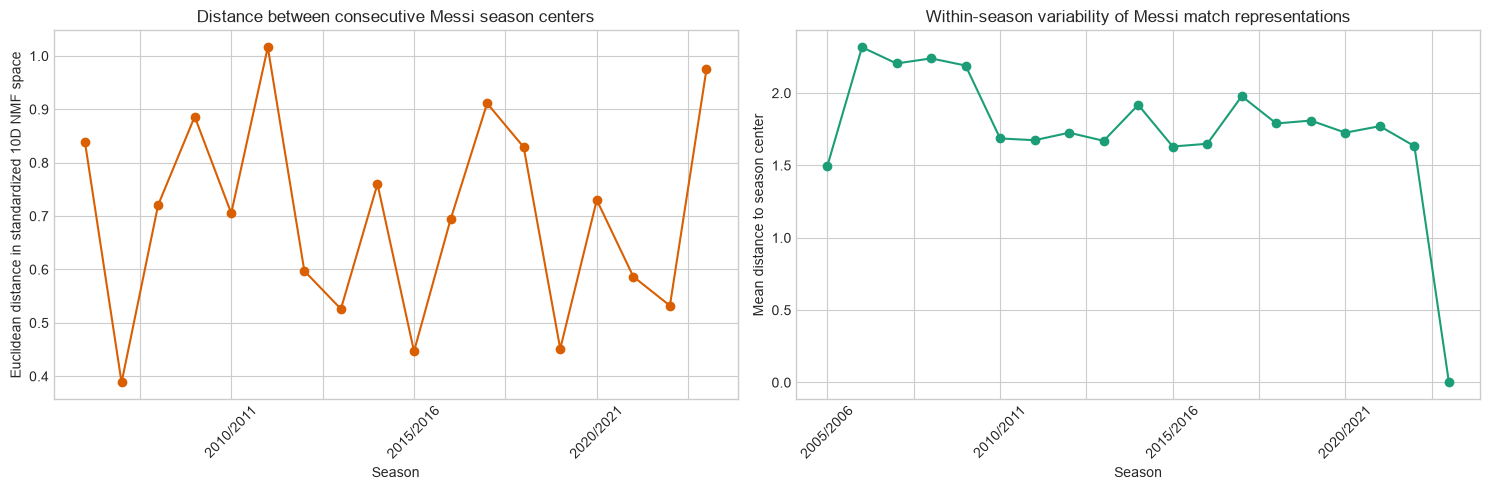

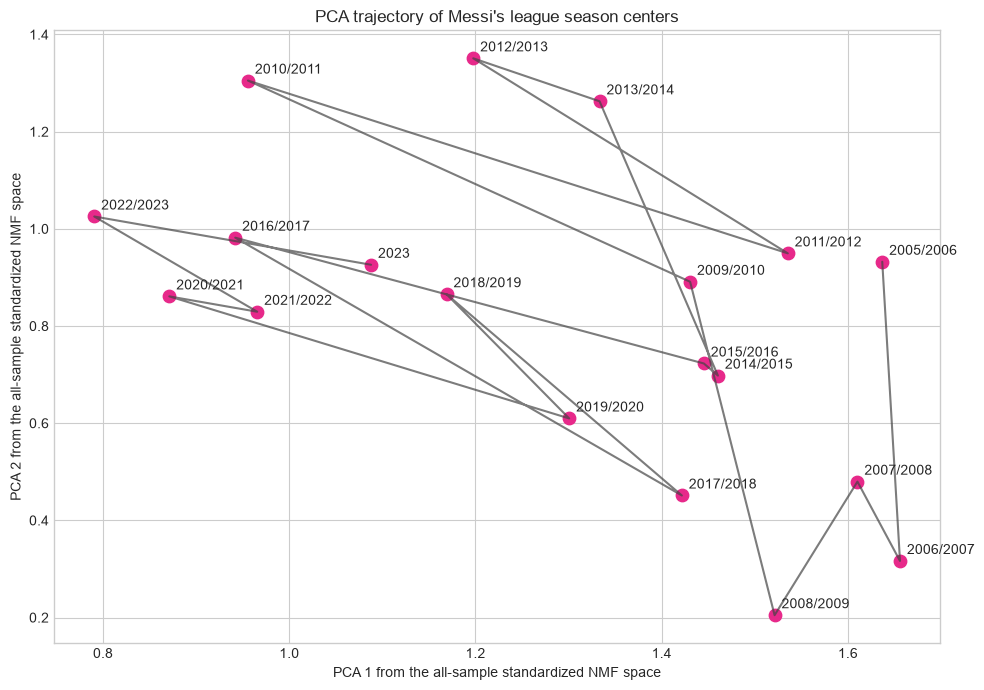

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
messi_season_summary["Consecutive-season distance"].plot(
    ax=axes[0], marker="o", color="#d95f02"
)
axes[0].set_title("Distance between consecutive Messi season centers")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Euclidean distance in standardized 10D NMF space")
axes[0].tick_params(axis="x", rotation=45)

messi_season_summary["Within-season variability"].plot(
    ax=axes[1], marker="o", color="#1b9e77"
)
axes[1].set_title("Within-season variability of Messi match representations")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Mean distance to season center")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

center_matrix = np.vstack([season_centers[season] for season in ordered_messi_seasons])
center_pca = pca_model.transform(center_matrix)
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(center_pca[:, 0], center_pca[:, 1], color="#444444", lw=1.5, alpha=0.7)
ax.scatter(center_pca[:, 0], center_pca[:, 1], s=80, color="#e7298a")
for season, (x_coordinate, y_coordinate) in zip(ordered_messi_seasons, center_pca):
    ax.annotate(season, (x_coordinate, y_coordinate), xytext=(5, 5), textcoords="offset points")
ax.set_title("PCA trajectory of Messi's league season centers")
ax.set_xlabel("PCA 1 from the all-sample standardized NMF space")
ax.set_ylabel("PCA 2 from the all-sample standardized NMF space")
plt.tight_layout()
plt.show()

# 15. Identify Possible Style Transitions

### Interpretation boundary

Consecutive pairs are ranked by distance in the full standardized ten-dimensional NMF space. For the three largest changes, the notebook compares cluster proportions, average component weights, average passing paths, sample size, and within-season variability.

A large distance means the model detects a relatively large shift in pass-path distribution. It may indicate a change in passing role, but event data alone cannot establish a cause. Team tactics, position, teammates, opposition, league environment, and dataset coverage may all contribute.

,Earlier season,Later season,Style-space distance
0,2010/2011,2011/2012,1.016
1,2022/2023,2023,0.975
2,2016/2017,2017/2018,0.911
3,2008/2009,2009/2010,0.886
4,2005/2006,2006/2007,0.838
5,2017/2018,2018/2019,0.829
6,2013/2014,2014/2015,0.760
7,2019/2020,2020/2021,0.730
8,2007/2008,2008/2009,0.721
9,2009/2010,2010/2011,0.705



2010/2011 → 2011/2012: distance 1.016. The model detects a relatively large shift in passing-path distribution. This may indicate a change in passing role, but team context and coverage are also plausible influences.


,Eligible matches,Within-season variability,Cluster 1 share,Cluster 2 share,Cluster 3 share,Cluster 4 share,Cluster 5 share,NMF Component 1,NMF Component 2,NMF Component 3,NMF Component 4,NMF Component 5,NMF Component 6,NMF Component 7,NMF Component 8,NMF Component 9,NMF Component 10
Season,,,,,,,,,,,,,,,,,
2010/2011,30,1.686,53.3%,10.0%,16.7%,13.3%,6.7%,0.0007,0.0098,0.0179,0.0029,0.0035,0.0302,0.0044,0.0041,0.0011,0.0041
2011/2012,29,1.674,51.7%,6.9%,13.8%,0.0%,27.6%,0.0006,0.0092,0.0076,0.0002,0.0001,0.0356,0.0119,0.0086,0.0015,0.0040


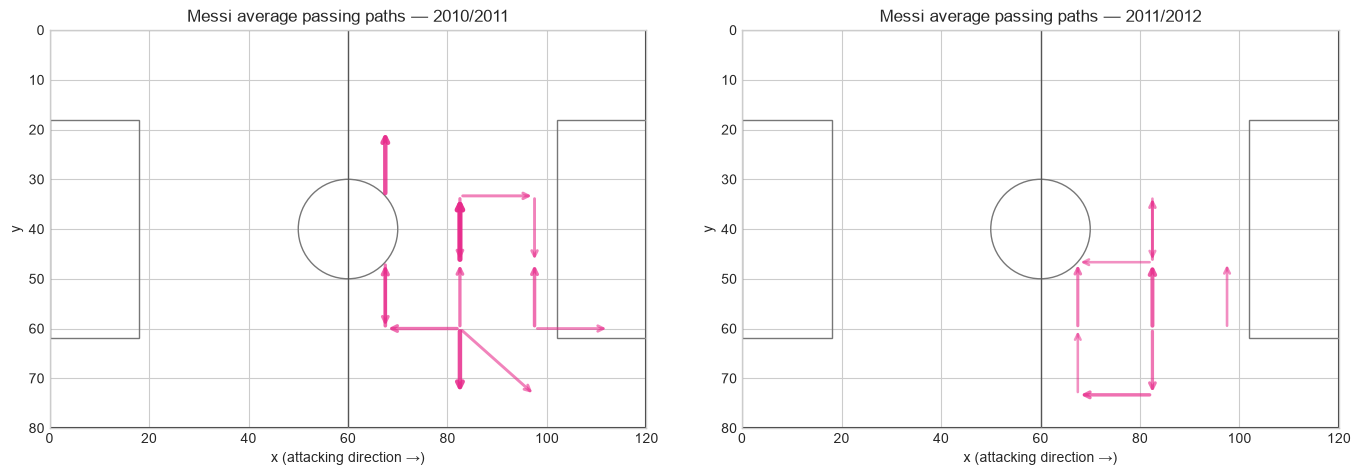


2022/2023 → 2023: distance 0.975. The model detects a relatively large shift in passing-path distribution. This may indicate a change in passing role, but team context and coverage are also plausible influences.


,Eligible matches,Within-season variability,Cluster 1 share,Cluster 2 share,Cluster 3 share,Cluster 4 share,Cluster 5 share,NMF Component 1,NMF Component 2,NMF Component 3,NMF Component 4,NMF Component 5,NMF Component 6,NMF Component 7,NMF Component 8,NMF Component 9,NMF Component 10
Season,,,,,,,,,,,,,,,,,
2022/2023,14,1.633,57.1%,14.3%,14.3%,7.1%,7.1%,0.0017,0.0074,0.0153,0.0003,0.0043,0.0248,0.0034,0.0076,0.0000,0.0059
2023,1,0.000,100.0%,0.0%,0.0%,0.0%,0.0%,0.0000,0.0116,0.0067,0.0000,0.0000,0.0235,0.0000,0.0000,0.0000,0.0000


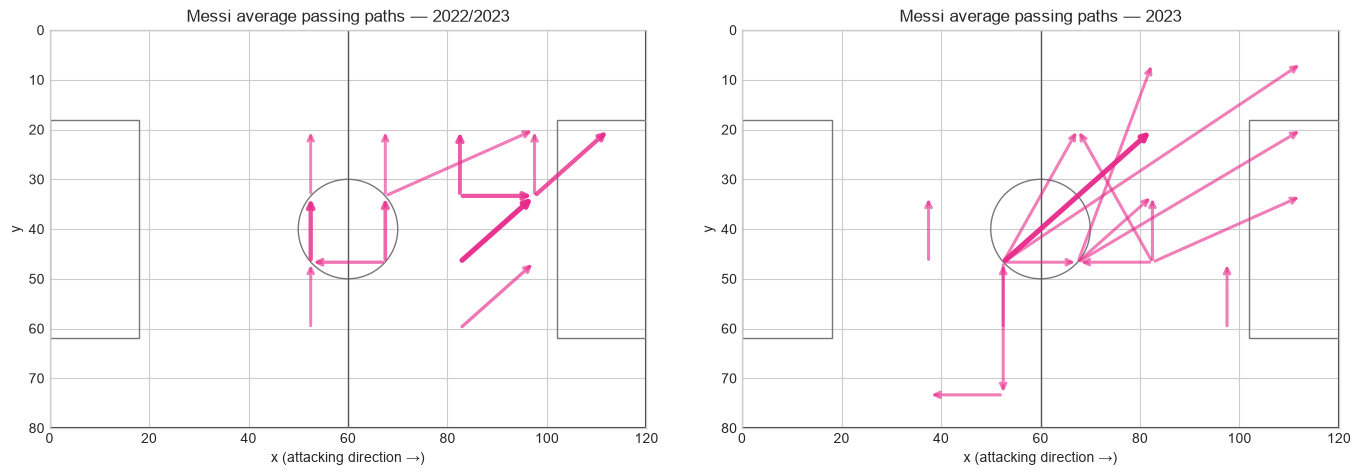


2016/2017 → 2017/2018: distance 0.911. The model detects a relatively large shift in passing-path distribution. This may indicate a change in passing role, but team context and coverage are also plausible influences.


,Eligible matches,Within-season variability,Cluster 1 share,Cluster 2 share,Cluster 3 share,Cluster 4 share,Cluster 5 share,NMF Component 1,NMF Component 2,NMF Component 3,NMF Component 4,NMF Component 5,NMF Component 6,NMF Component 7,NMF Component 8,NMF Component 9,NMF Component 10
Season,,,,,,,,,,,,,,,,,
2016/2017,24,1.650,70.8%,16.7%,12.5%,0.0%,0.0%,0.0001,0.0083,0.0108,0.0002,0.0002,0.0257,0.0015,0.0068,0.0003,0.0073
2017/2018,7,1.978,42.9%,14.3%,28.6%,0.0%,14.3%,0.0000,0.0123,0.0065,0.0052,0.0000,0.0260,0.0090,0.0155,0.0001,0.0029


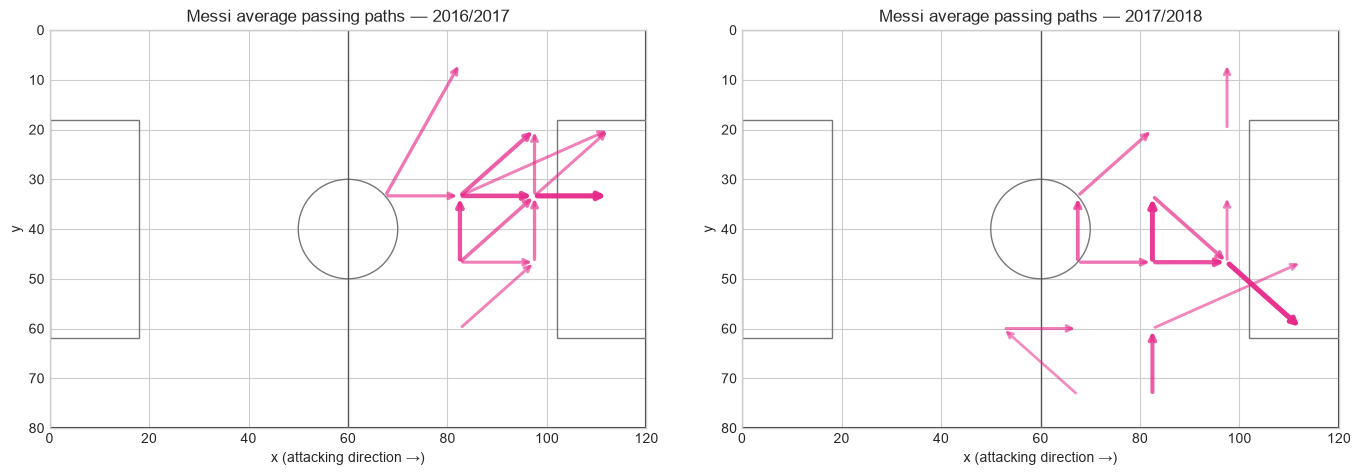

In [20]:
transition_rows = []
for previous_season, current_season in zip(
    ordered_messi_seasons[:-1], ordered_messi_seasons[1:]
):
    transition_rows.append(
        {
            "Earlier season": previous_season,
            "Later season": current_season,
            "Style-space distance": float(
                np.linalg.norm(
                    season_centers[current_season] - season_centers[previous_season]
                )
            ),
        }
    )
transition_ranking = pd.DataFrame(transition_rows).sort_values(
    "Style-space distance", ascending=False
)
display(transition_ranking.reset_index(drop=True).style.format({"Style-space distance": "{:.3f}"}))

top_transitions = transition_ranking.head(3)
for _, transition in top_transitions.iterrows():
    earlier = transition["Earlier season"]
    later = transition["Later season"]
    seasons = [earlier, later]
    groups = [messi_metadata[messi_metadata["season_name"].eq(season)] for season in seasons]

    print(
        f"\n{earlier} → {later}: distance {transition['Style-space distance']:.3f}. "
        "The model detects a relatively large shift in passing-path distribution. "
        "This may indicate a change in passing role, but team context and coverage "
        "are also plausible influences."
    )
    comparison_rows = []
    average_routes = []
    for season, group in zip(seasons, groups):
        indices = group.index.to_numpy()
        cluster_percentages = group["primary_cluster"].value_counts(normalize=True)
        comparison_row = {
            "Season": season,
            "Eligible matches": len(group),
            "Within-season variability": messi_season_summary.loc[
                season, "Within-season variability"
            ],
        }
        for cluster_number in range(1, CONFIG["gmm_clusters"] + 1):
            comparison_row[f"Cluster {cluster_number} share"] = cluster_percentages.get(
                cluster_number, 0.0
            )
        for component in component_columns:
            comparison_row[component] = group[component].mean()
        comparison_rows.append(comparison_row)
        average_routes.append(np.asarray(X_routes[indices].mean(axis=0)).ravel())

    display(
        pd.DataFrame(comparison_rows).set_index("Season").style.format(
            {
                **{
                    f"Cluster {cluster_number} share": "{:.1%}"
                    for cluster_number in range(1, CONFIG["gmm_clusters"] + 1)
                },
                **{component: "{:.4f}" for component in component_columns},
                "Within-season variability": "{:.3f}",
            }
        )
    )
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
    for ax, season, average_route in zip(axes, seasons, average_routes):
        plot_route_vector(
            ax,
            average_route,
            f"Messi average passing paths — {season}",
            top_n=18,
            color="#e7298a",
        )
    plt.tight_layout()
    plt.show()

# 16. Basic Robustness Checks

## Check A: Cluster-position relationship

The row-normalized contingency table shows how each explicit attacking position is distributed over clusters. Cramér's V summarizes association strength without implying causality. A high value would suggest that the model partly separates position labels rather than a position-independent style.

In [21]:
position_cluster_counts = pd.crosstab(
    sample_metadata["primary_attacking_position"],
    sample_metadata["primary_cluster"],
)
position_cluster_percentages = pd.crosstab(
    sample_metadata["primary_attacking_position"],
    sample_metadata["primary_cluster"],
    normalize="index",
)
chi2, _, _, _ = chi2_contingency(position_cluster_counts)
n_observations = position_cluster_counts.to_numpy().sum()
minimum_dimension = min(position_cluster_counts.shape) - 1
cramers_v = math.sqrt(chi2 / (n_observations * minimum_dimension))
display(position_cluster_counts)
display(position_cluster_percentages.style.format("{:.1%}"))
print(f"Cramér's V for position and cluster: {cramers_v:.3f}")
if cramers_v >= 0.5:
    print("The clusters are strongly associated with explicit attacking position.")
elif cramers_v >= 0.3:
    print("The clusters have a moderate association with explicit attacking position.")
else:
    print("The clusters are not strongly dominated by explicit attacking position.")

primary_cluster,1,2,3,4,5
primary_attacking_position,,,,,
Center Attacking Midfield,184,79,453,236,277
Center Forward,204,76,245,123,135
Left Attacking Midfield,1,15,24,24,19
Left Wing,30,568,232,478,154
Right Attacking Midfield,34,4,27,5,15
Right Wing,719,21,319,71,332


primary_cluster,1,2,3,4,5
primary_attacking_position,,,,,
Center Attacking Midfield,15.0%,6.4%,36.9%,19.2%,22.5%
Center Forward,26.1%,9.7%,31.3%,15.7%,17.2%
Left Attacking Midfield,1.2%,18.1%,28.9%,28.9%,22.9%
Left Wing,2.1%,38.9%,15.9%,32.7%,10.5%
Right Attacking Midfield,40.0%,4.7%,31.8%,5.9%,17.6%
Right Wing,49.2%,1.4%,21.8%,4.9%,22.7%


Cramér's V for position and cluster: 0.323
The clusters have a moderate association with explicit attacking position.


## Check B: Cluster-team relationship

This table lists the teams with the most samples inside each cluster and their within-cluster shares. Concentration among a few teams would indicate that possession structure and dataset coverage influence the learned patterns.

In [22]:
team_concentration_rows = []
for cluster_number in range(1, CONFIG["gmm_clusters"] + 1):
    cluster_teams = sample_metadata.loc[
        sample_metadata["primary_cluster"].eq(cluster_number), "team"
    ]
    counts = cluster_teams.value_counts().head(8)
    for rank, (team, count) in enumerate(counts.items(), start=1):
        team_concentration_rows.append(
            {
                "Cluster": cluster_number,
                "Rank": rank,
                "Team": team,
                "Samples": count,
                "Share within cluster": count / len(cluster_teams),
            }
        )
team_concentration = pd.DataFrame(team_concentration_rows)
display(
    team_concentration.pivot(
        index="Rank", columns="Cluster", values=["Team", "Share within cluster"]
    )
)
print(
    "Team concentration is evidence that these clusters may reflect a mixture of "
    "individual passing style and team possession structure."
)

Team                                            \
Cluster                    1                    2                    3   
Rank                                                                     
1                  Barcelona            Barcelona            Barcelona   
2        Paris Saint-Germain  Paris Saint-Germain              Chelsea   
3                     Napoli               Napoli  Paris Saint-Germain   
4              Athletic Club           Celta Vigo          Real Madrid   
5              Real Sociedad             Valencia              Sevilla   
6                  AS Monaco      Manchester City              Arsenal   
7                     Nantes           Stoke City           Celta Vigo   
8                    Everton        Athletic Club           Stoke City   

                                                  Share within cluster  \
Cluster                    4                    5                    1   
Rank                                                                     
1                  Barcelona            Barcelona             0.280717   
2        Paris Saint-Germain     Bayer Leverkusen             0.040956   
3           Bayer Leverkusen        Athletic Club             0.020478   
4              Real Sociedad          Real Madrid             0.019625   
5                    Chelsea  Paris Saint-Germain             0.018771   
6                Real Madrid               Troyes             0.017918   
7                      Lille        Saint-Étienne             0.017918   
8                    Arsenal     Newcastle United             0.017065   

                                                 
Cluster         2         3         4         5  
Rank                                             
1        0.294889  0.127692  0.129136  0.121245  
2        0.055046  0.035385  0.044824  0.026824  
3        0.023591  0.031538  0.026681  0.024678  
4         0.02228  0.029231  0.024546  0.022532  
5         0.02097  0.025385  0.023479  0.022532  
6        0.019659  0.023846  0.022412  0.022532  
7        0.019659  0.021538  0.021345  0.022532  
8        0.018349  0.021538  0.020277  0.021459

Team concentration is evidence that these clusters may reflect a mixture of individual passing style and team possession structure.


## Check C: Minimum-pass threshold

The original model is not retrained. Instead, Messi's season distribution is recalculated after requiring at least 20 valid passes. This isolates whether low-volume Messi matches are driving the season pattern while keeping the learned reference space fixed.

In [23]:
higher_threshold = 20
messi_higher_passes = messi_metadata[
    messi_metadata["valid_passes"].ge(higher_threshold)
].copy()
threshold_rows = []
for season in ordered_messi_seasons:
    original = messi_metadata[messi_metadata["season_name"].eq(season)]
    stricter = messi_higher_passes[messi_higher_passes["season_name"].eq(season)]
    row = {
        "Season": season,
        "Original matches": len(original),
        f"Matches with at least {higher_threshold} passes": len(stricter),
    }
    l1_difference = 0.0
    for cluster_number in range(1, CONFIG["gmm_clusters"] + 1):
        original_share = original["primary_cluster"].eq(cluster_number).mean()
        stricter_share = (
            stricter["primary_cluster"].eq(cluster_number).mean()
            if len(stricter)
            else np.nan
        )
        row[f"Original Cluster {cluster_number} share"] = original_share
        row[f"Higher-threshold Cluster {cluster_number} share"] = stricter_share
        if np.isfinite(stricter_share):
            l1_difference += abs(original_share - stricter_share)
    row["Total absolute cluster-share change"] = (
        l1_difference if len(stricter) else np.nan
    )
    threshold_rows.append(row)

threshold_comparison = pd.DataFrame(threshold_rows).set_index("Season")
display(
    threshold_comparison.style.format(
        {
            column: "{:.1%}"
            for column in threshold_comparison.columns
            if "share" in column.lower() or "change" in column.lower()
        }
    )
)
print(
    "Smaller total absolute cluster-share changes indicate that the main season "
    "pattern is less sensitive to raising the pass threshold."
)

,Original matches,Matches with at least 20 passes,Original Cluster 1 share,Higher-threshold Cluster 1 share,Original Cluster 2 share,Higher-threshold Cluster 2 share,Original Cluster 3 share,Higher-threshold Cluster 3 share,Original Cluster 4 share,Higher-threshold Cluster 4 share,Original Cluster 5 share,Higher-threshold Cluster 5 share,Total absolute cluster-share change
Season,,,,,,,,,,,,,
2005/2006,5,1,60.0%,100.0%,0.0%,0.0%,40.0%,0.0%,0.0%,0.0%,0.0%,0.0%,80.0%
2006/2007,17,8,64.7%,50.0%,5.9%,0.0%,23.5%,37.5%,0.0%,0.0%,5.9%,12.5%,41.2%
2007/2008,13,9,69.2%,88.9%,7.7%,11.1%,23.1%,0.0%,0.0%,0.0%,0.0%,0.0%,46.2%
2008/2009,21,15,42.9%,40.0%,4.8%,6.7%,14.3%,13.3%,4.8%,0.0%,33.3%,40.0%,17.1%
2009/2010,23,19,52.2%,52.6%,8.7%,5.3%,21.7%,21.1%,4.3%,5.3%,13.0%,15.8%,8.2%
2010/2011,30,27,53.3%,51.9%,10.0%,11.1%,16.7%,18.5%,13.3%,11.1%,6.7%,7.4%,7.4%
2011/2012,29,27,51.7%,51.9%,6.9%,3.7%,13.8%,14.8%,0.0%,0.0%,27.6%,29.6%,6.4%
2012/2013,25,21,80.0%,81.0%,12.0%,9.5%,4.0%,4.8%,0.0%,0.0%,4.0%,4.8%,5.0%
2013/2014,21,15,52.4%,60.0%,14.3%,13.3%,23.8%,20.0%,4.8%,0.0%,4.8%,6.7%,19.0%


Smaller total absolute cluster-share changes indicate that the main season pattern is less sensitive to raising the pass threshold.


## Check D: Cluster uncertainty

Maximum posterior probability measures how confidently the GMM assigns a primary cluster. Low-confidence matches can combine several learned passing patterns or sit between cluster centers.

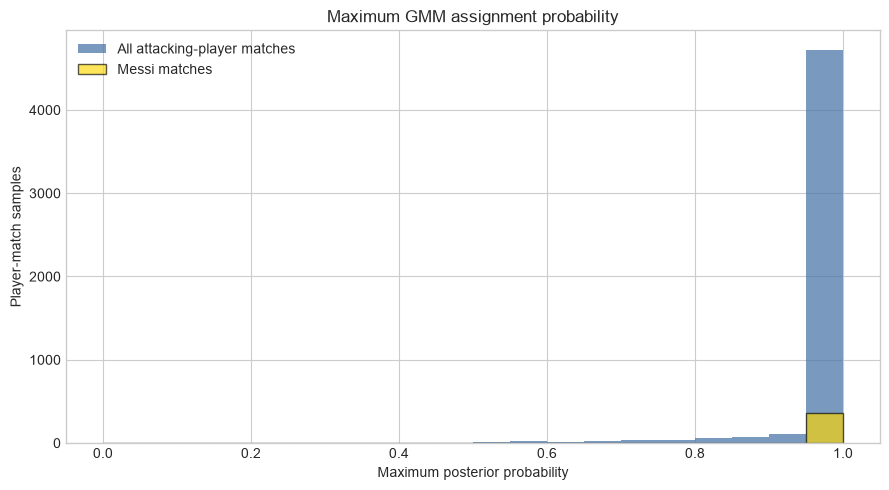

,match_date,season_name,team,opponent,primary_cluster,maximum_cluster_probability,valid_passes
0,2019-12-18,2019/2020,Barcelona,Real Madrid,1,0.545677,22
1,2023-05-21,2022/2023,Paris Saint-Germain,Auxerre,3,0.653934,27
2,2011-03-05,2010/2011,Barcelona,Real Zaragoza,5,0.655522,43
3,2011-04-30,2010/2011,Barcelona,Real Sociedad,4,0.664087,19
4,2017-01-22,2016/2017,Barcelona,Eibar,1,0.702155,25
5,2012-11-25,2012/2013,Barcelona,Levante UD,1,0.743668,35
6,2017-05-14,2016/2017,Barcelona,Las Palmas,1,0.795434,20
7,2005-12-11,2005/2006,Barcelona,Sevilla,3,0.817610,15
8,2017-04-05,2016/2017,Barcelona,Sevilla,3,0.848808,38
9,2022-05-14,2021/2022,Paris Saint-Germain,Montpellier,4,0.855071,51


These low-confidence matches may combine multiple passing patterns; their hard cluster labels should be interpreted cautiously.


In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(
    sample_metadata["maximum_cluster_probability"],
    bins=np.linspace(0, 1, 21),
    alpha=0.75,
    color="#4c78a8",
    label="All attacking-player matches",
)
ax.hist(
    messi_metadata["maximum_cluster_probability"],
    bins=np.linspace(0, 1, 21),
    alpha=0.65,
    color="gold",
    edgecolor="black",
    label="Messi matches",
)
ax.set_title("Maximum GMM assignment probability")
ax.set_xlabel("Maximum posterior probability")
ax.set_ylabel("Player-match samples")
ax.legend()
plt.tight_layout()
plt.show()

low_confidence_messi = messi_metadata.nsmallest(
    min(12, len(messi_metadata)), "maximum_cluster_probability"
)[
    [
        "match_date",
        "season_name",
        "team",
        "opponent",
        "primary_cluster",
        "maximum_cluster_probability",
        "valid_passes",
    ]
]
display(low_confidence_messi.reset_index(drop=True))
print(
    "These low-confidence matches may combine multiple passing patterns; their "
    "hard cluster labels should be interpreted cautiously."
)

# 17. Final Conclusions

The next cell produces a concise data-dependent summary. Its language deliberately distinguishes model-detected passing-path change from causal or complete playing-style claims.

In [25]:
reliable_seasons = messi_season_summary[
    messi_season_summary["Reliability flag"].eq("Reliable baseline")
]
largest_transitions_text = (
    "; ".join(
        f"{row['Earlier season']} → {row['Later season']} "
        f"({row['Style-space distance']:.3f})"
        for _, row in transition_ranking.head(3).iterrows()
    )
    if not transition_ranking.empty
    else "No consecutive season pair was available"
)
variability_high = messi_season_summary["Within-season variability"].idxmax()
variability_low = messi_season_summary["Within-season variability"].idxmin()

print("Final conclusions")
print("-----------------")
print(
    f"1. The model was trained on {len(sample_metadata):,} attacking-player match "
    f"samples from {sample_metadata['competition_name'].nunique()} domestic leagues "
    f"and {sample_metadata[['competition_name', 'season_name']].drop_duplicates().shape[0]} "
    "competition-season combinations."
)
print(
    f"2. Messi contributed {len(messi_metadata):,} eligible domestic-league matches "
    f"across {messi_metadata['season_name'].nunique()} seasons; "
    f"{len(reliable_seasons)} seasons met the minimum reliability threshold."
)
print("3. The learned NMF components broadly emphasize:")
for label, interpretation in zip(component_columns, component_interpretations):
    print(f"   - {label}: {interpretation.split('.')[0].lower()}.")
print(
    "4. The five GMM clusters summarize recurring combinations of these route "
    "components. The position and team checks show that the clusters can reflect "
    "passing style, attacking position, and possession context together."
)
print(f"5. The largest model-detected consecutive season changes were: {largest_transitions_text}.")
print(
    f"6. Within-season passing-role variability was highest in {variability_high} "
    f"and lowest in {variability_low} under this representation."
)
print(
    f"7. Position-cluster association had Cramér's V = {cramers_v:.3f}; team "
    "concentration tables also indicate that context should not be separated from "
    "the learned style labels without further tests."
)
print(
    "8. These findings describe passing-style evolution only. They do not measure "
    "Messi's complete playing style, overall performance, or causal tactical change."
)

Final conclusions
-----------------
1. The model was trained on 5,104 attacking-player match samples from 9 domestic leagues and 31 competition-season combinations.
2. Messi contributed 382 eligible domestic-league matches across 19 seasons; 18 seasons met the minimum reliability threshold.
3. The learned NMF components broadly emphasize:
   - NMF Component 1: this component appears to emphasize short or lateral circulation through the low-y flank.
   - NMF Component 2: this component appears to emphasize short or lateral circulation through the high-y flank.
   - NMF Component 3: this component appears to emphasize short or lateral circulation through the low-y flank.
   - NMF Component 4: this component appears to emphasize short or lateral circulation through the low-y flank.
   - NMF Component 5: this component appears to emphasize short or lateral circulation through the low-y flank.
   - NMF Component 6: this component appears to emphasize short or lateral circulation through cen

## Limitations and Next Steps

- StatsBomb open-data coverage is incomplete and does not provide every Messi season or every match in each included league.
- Messi's records may come from different league and team environments, so distances can reflect context as well as personal passing choices.
- Timed lineup position labels can be missing, uncertain, or too coarse; players without usable explicit attacking intervals are excluded.
- The experiment excludes carries, shots, receptions, defensive actions, pressing, and off-ball movement.
- Teammates and team possession structures influence which passes are available and therefore influence both NMF components and clusters.
- Some Messi seasons may have small eligible samples even when they remain visible in the tables.
- Aggregating passes into a transition matrix removes exact event sequence, possession order, pressure, body orientation, and game-state detail.
- NMF and GMM results depend on grid size, thresholds, component count, cluster count, and dataset coverage.
- A later experiment should compare NMF + GMM with a simpler baseline, such as direct summary features with k-means or season-level route distances.

The next step should be a pre-registered sensitivity analysis across a small set of reasonable grid and threshold choices, followed by a simpler baseline comparison. Any tactical explanation should then be checked against video or independent contextual data rather than inferred from event locations alone.